# Imports

In [36]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from math import sqrt, erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import WhiteKernel as W
import pickle
from tqdm import tqdm

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from WCDRF.base import *
from WCDRF.synthetic_data_generation import *

# Data loading and preprocessing

In [ ]:
amicas_df = pd.read_csv("data/BIS.csv")

In [5]:
# amicas_df[["PatientID","id","age","height","weight","sex","Remifentanil","Atracurium","Dopamine","SNP"]].drop_duplicates().to_csv("BIC_with_meds.csv",index=False)

In [6]:
Time_allowed = [10.0,30.0,60.0,80.0,100.0,120.0,150.0,170.0,200.0,220.0,250.0,300.0]
amicas_df = amicas_df[amicas_df.Time.isin(Time_allowed)]
amicas_df = amicas_df[amicas_df["Remifentanil"] == 0]

In [93]:
class NormalDist:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale

    def pdf(self, X):
        return 1/np.sqrt(2 * np.pi * (self.scale**2)) * np.exp(-((X - self.loc)**2) / (2 * self.scale**2))
    
    def interval(self, confidence):
        p = confidence/2.0
        return self.loc + self.scale * np.sqrt(2) * erfinv(2*(0.5-p) - 1), self.loc + self.scale * np.sqrt(2) * erfinv(2*(0.5+p) - 1)

class NormalDistAmicas:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale

    def pdf(self, X):
        zero_five_array = 0.5 * (1 + erf((0.05 - self.loc)/(sqrt(2)*self.scale)))
        pdf_array = 1/np.sqrt(2 * np.pi * (self.scale**2)) * np.exp(-((X - self.loc)**2) / (2 * self.scale**2))
        zero_five_bool = np.array(X) == 0.05

        return zero_five_bool * zero_five_array + (1-zero_five_array) * pdf_array
    
    def interval(self, confidence):
        p_zero_five = 0.5 * (1 + erf((0.05 - self.loc)/(sqrt(2)*self.scale)))
        p = confidence/2.0

        if 0.5-p <= p_zero_five:
            return_first_arg = 0.05 
        else:
            return_first_arg = self.loc + self.scale * np.sqrt(2) * erfinv(2*(0.5-p) - 1)

        if 0.5+p <= p_zero_five:
            return_second_arg = 0.05 
        else:
            return_second_arg = self.loc + self.scale * np.sqrt(2) * erfinv(2*(0.5+p) - 1)

        return return_first_arg, return_second_arg


class amicas_datagenerator():
    def __init__(self):
        return 

    def get_treatment_mean(self, X):
        return NormalDist(loc = 0.05 + (0.0005*X[:,1]**2+0.3*(X[:,5]/40)**3+0.4*np.exp(X[:,6]/40))/25, scale = 0.1)
        # return NormalDistAmicas(loc = 0.05 + (0.0005*X[:,1]**2+0.3*(X[:,5]/40)**3+0.4*np.exp(X[:,6]/40))/25, scale = 0.1)

    def get_treatment_std(self, X):
        return (self.get_treatment_mean(X).interval(0.6827)[1] - self.get_treatment_mean(X).interval(0.6827)[0])/2
    
    def add_noise(self, X, T):
        return np.random.normal(0,(np.abs(T - self.get_treatment_mean(X).loc)/0.1)**2  * ( (1 - (X[:,1] < 69)) * 3 + ((X[:,1] < 69)) * 6))



In [27]:
prop_function_mean = 0.05 + (0.0005*amicas_df.age**2+0.3*(amicas_df.bmi/40)**3+0.4*np.exp(amicas_df.lbm/40))/25
amicas_df['BISData_noise'] = amicas_df['BISData'] + np.random.normal(0,(np.abs(amicas_df['Propofol'] - prop_function_mean)/0.1)**2  * ( (1 - ((amicas_df.age < 69).values)) * 3 + (((amicas_df.age < 69).values)) * 6))
amicas_df['BISData_noise'] = np.max([np.repeat(0,len(amicas_df)),np.min([np.repeat(100,len(amicas_df)),amicas_df['BISData_noise'].values],axis=0)],axis=0)

In [28]:
treatment = "Propofol"

outcome = 'BISData_noise'

features = [
    'Time', 
    'age', 
    'height', 
    'weight',
    'sex', 
    'bmi', 
    'lbm', 
    'Remifentanil', 
    'Atracurium',
    'Dopamine', 
    'SNP', 
    'Dist_type'
]

<Axes: >

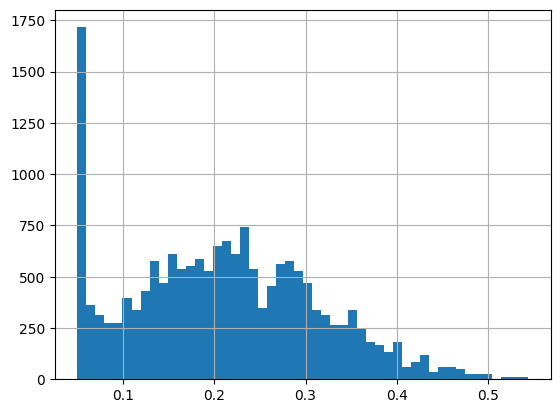

In [29]:
amicas_df[treatment].hist(bins=50)

In [ ]:
BIS_counterfactual_df = pd.read_csv("data/BIS_counterfactual.csv")
basic_features_amicas_df = amicas_df[['PatientID', 'id', 'age', 'height', 'weight',
       'sex', 'bmi', 'lbm','Remifentanil', 'Atracurium',
       'Dopamine', 'SNP', 'Dist_type']].drop_duplicates().reset_index(drop=True)
BIS_counterfactual_df = BIS_counterfactual_df.merge(basic_features_amicas_df,how="left",on="PatientID")
BIS_counterfactual_df["propofol_treat_numb"] = BIS_counterfactual_df["inner_loop"] - (BIS_counterfactual_df["PatientID"]-1)*46

BIS_counterfactual_df = BIS_counterfactual_df[BIS_counterfactual_df.Time.isin(Time_allowed)]

BIS_counterfactual_df = BIS_counterfactual_df[BIS_counterfactual_df.PatientID.isin(amicas_df.PatientID.unique())]

prop_arr = np.arange(0.05,0.51,0.01)
def propofol_apply(row):
    return prop_arr[row-1]

BIS_counterfactual_df["Propofol"] = BIS_counterfactual_df["propofol_treat_numb"].apply(propofol_apply)
BIS_counterfactual_df["Propofol"] = np.round(BIS_counterfactual_df["Propofol"],2)
BIS_counterfactual_df = BIS_counterfactual_df[["PatientID","Time","BISData","Propofol"]]

# Train test split

In [85]:
full_train_patient_ids, test_patient_ids = train_test_split(amicas_df.PatientID.unique(),  test_size=0.2, random_state=42)

df_training_full_final_df = amicas_df[amicas_df.PatientID.isin(full_train_patient_ids)]
df_test_final_df = amicas_df[amicas_df.PatientID.isin(test_patient_ids)]

train_stay_ids, calibration_stay_ids = train_test_split(full_train_patient_ids,  test_size=0.5, random_state=42)

df_training_final_df = df_training_full_final_df[df_training_full_final_df.PatientID.isin(train_stay_ids)]
df_calibration_final_df = df_training_full_final_df[df_training_full_final_df.PatientID.isin(calibration_stay_ids)]


In [86]:
CATBOOST_propensity_model = CatBoostRegressor(iterations=500,verbose=50,use_best_model=True)
C_DRF_CATBOOST_base = CatBoostRegressor(iterations=300,verbose=50,use_best_model=False)#,"trauma_flag"])

CPS_C_DRF_CATBOOST_base = DRFWrapRegressor(CATBOOST_propensity_model, C_DRF_CATBOOST_base)
CPS_C_DRF_CATBOOST_base.fit(df_training_final_df[features+[treatment]], df_training_final_df[outcome])#, eval_set=(df_test_final_df[features+[treatment]], df_test_final_df[outcome]))

CPS_C_DRF_CATBOOST_base.fit_propensity(df_training_final_df[features], df_training_final_df[treatment].values, eval_set=(df_calibration_final_df[features], df_calibration_final_df[treatment]))
CPS_C_DRF_CATBOOST_base.calibrate_propensity(df_calibration_final_df[features], df_calibration_final_df[treatment].values)

Learning rate set to 0.147645
0:	learn: 25.2994878	total: 2.24ms	remaining: 669ms
50:	learn: 5.5775272	total: 128ms	remaining: 624ms
100:	learn: 5.1397255	total: 308ms	remaining: 607ms
150:	learn: 4.8390025	total: 442ms	remaining: 437ms
200:	learn: 4.6074194	total: 593ms	remaining: 292ms
250:	learn: 4.3980813	total: 731ms	remaining: 143ms
299:	learn: 4.2295984	total: 854ms	remaining: 0us
Learning rate set to 0.105106
0:	learn: 0.1018629	test: 0.1040960	best: 0.1040960 (0)	total: 2.62ms	remaining: 1.31s
50:	learn: 0.0693145	test: 0.0989702	best: 0.0978278 (26)	total: 152ms	remaining: 1.33s
100:	learn: 0.0578778	test: 0.1006579	best: 0.0978278 (26)	total: 278ms	remaining: 1.1s
150:	learn: 0.0481050	test: 0.1017458	best: 0.0978278 (26)	total: 402ms	remaining: 929ms
200:	learn: 0.0403905	test: 0.1032318	best: 0.0978278 (26)	total: 526ms	remaining: 782ms
250:	learn: 0.0344545	test: 0.1040119	best: 0.0978278 (26)	total: 663ms	remaining: 658ms
300:	learn: 0.0297140	test: 0.1047388	best: 0.097

In [87]:
from sklearn.metrics import r2_score
r2_score(df_test_final_df[outcome],CPS_C_DRF_CATBOOST_base.learner.predict(df_test_final_df[features+[treatment]]))

0.9578803101114679

# Single Example

In [88]:
cov_range = np.array([0.85,0.9,0.95,0.99])#0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.85,0.9,0.95,0.99])
VAR_prop_bandwidth = 0.02

cal_df = df_calibration_final_df.copy(deep=True)
test_df = df_test_final_df.copy(deep=True)

plot_W_min = df_training_final_df[treatment].min()
plot_W_max = df_training_final_df[treatment].max()

y_min_calibration = df_calibration_final_df[outcome].min()
y_max_calibration = df_calibration_final_df[outcome].max()

CPS_C_DRF_CATBOOST_base.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)

CATBOOST_bounds_cov_dict = {}


100%|██████████| 2/2 [00:18<00:00,  9.41s/it]


In [89]:
amicas_datagenerator_object = amicas_datagenerator()
OraclePropensityWrapperObject = OraclePropensityWrapper(amicas_datagenerator_object)

#oracle standard
CPS_C_DRF_CATBOOST_ORACLE = DRFWrapRegressor(OraclePropensityWrapperObject, CatBoostRegressor(verbose=False,iterations=1000,use_best_model=True), oracle_propensity=True)
CPS_C_DRF_CATBOOST_ORACLE.fit(df_training_final_df[features+[treatment]], df_training_final_df[outcome].values,eval_set=(df_test_final_df[features+[treatment]],df_test_final_df[outcome]))

ORACLE_WCDRF_local_prop = CPS_C_DRF_CATBOOST_ORACLE

ORACLE_WCDRF_local_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)
# ORACLE_WCDRF_global_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)

# ORACLE_WCDRF_global_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, cps=cps_setting, use_propensity = True, local_conditional_mode=False)



In [90]:
# treatment_range = np.arange(6.0,20.0,0.2)
treatment_range = np.arange(0.05,0.51,0.01)

not_oracle_test_bool = False

chosen_idx = np.random.randint(0,len(test_df),1)[0]

#prone position  (7)
# chosen_idx = 282
# no prone position (3)
# chosen_idx = 283

sample = test_df.iloc[chosen_idx].copy(deep=True)
# sample.loc["Time"] = 100
# sample.loc["Remifentanil"] = 0.1#0.2
# sample.loc["Atracurium"] = 10.0
# sample.loc["Dopamine"] = 5
# sample.loc["SNP"] = 5

effective_sample_rate_arr = []

for d_t in tqdm(treatment_range):

    sample_copy_df = pd.DataFrame(sample[features+[treatment]].values.reshape(1,-1),columns=features+[treatment])
    sample_copy_df[treatment] = d_t


    if not_oracle_test_bool:
        CPS_C_DRF_CATBOOST_base.calibrate(cal_df[features+[treatment]], df_calibration_final_df[outcome].values, cal_df[treatment].values, target_treatment=d_t, cps=True, local_conditional_mode=True,use_propensity=True)
        effective_sample_rate_arr.append(CPS_C_DRF_CATBOOST_base.effective_sample_rate)
    else:
        ORACLE_WCDRF_local_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, target_treatment=d_t, local_conditional_mode=True, use_propensity = True)
        effective_sample_rate_arr.append(ORACLE_WCDRF_local_prop.effective_sample_rate)

    CATBOOST_bounds_cov_dict_local = {}

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if not_oracle_test_bool:
            CATBOOST_bounds_matrix = CPS_C_DRF_CATBOOST_base.predict_multi_int(
                                        X=sample_copy_df[features+[treatment]].values,
                                        y_min=0,#y_min_calibration - 14*np.abs(y_min_calibration),
                                        y_max=100,#y_max_calibration + 14*np.abs(y_max_calibration),
                                        confidence_range=cov_range
                                        )
        else:
        
            CATBOOST_bounds_matrix = ORACLE_WCDRF_local_prop.predict_multi_int(
                                        X=sample_copy_df[features+[treatment]].values,
                                        y_min=0,#y_min_calibration - 14*np.abs(y_min_calibration),
                                        y_max=100,#y_max_calibration + 14*np.abs(y_max_calibration),
                                        confidence_range=cov_range
                                        )

    for cov, cov_idx in zip(cov_range,range(len(cov_range))):

            CATBOOST_bounds = CATBOOST_bounds_matrix[cov_idx, :, :]
            CATBOOST_bounds_cov_dict_local[cov] = CATBOOST_bounds



    CATBOOST_bounds_cov_dict[d_t] = CATBOOST_bounds_cov_dict_local


100%|██████████| 46/46 [00:00<00:00, 85.24it/s]


## Plot

In [91]:
plot_df_single_sample = BIS_counterfactual_df[(BIS_counterfactual_df.Time==sample.Time)&(BIS_counterfactual_df.PatientID == sample.PatientID)]

prop_function_mean = 0.05 + (0.0005*sample.age**2+0.3*(sample.bmi/40)**3+0.4*np.exp(sample.lbm/40))/25

plot_df_single_sample['BISData_noise'] = plot_df_single_sample['BISData'] + np.random.normal(0,(np.abs(plot_df_single_sample['Propofol'] - prop_function_mean)/0.1)**2  * ( (1 - ((sample.age < 69))) * 3 + (((sample.age < 69))) * 6))
plot_df_single_sample['BISData_noise'] = np.max([np.repeat(0,len(plot_df_single_sample)),np.min([np.repeat(100,len(plot_df_single_sample)),plot_df_single_sample['BISData_noise'].values],axis=0)],axis=0)
# plot_df_single_sample

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\1110639725.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_single_sample['BISData_noise'] = plot_df_single_sample['BISData'] + np.random.normal(0,(np.abs(plot_df_single_sample['Propofol'] - prop_function_mean)/0.1)**2  * ( (1 - ((sample.age < 69))) * 3 + (((sample.age < 69))) * 6))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\1110639725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_single_sample['BISData_noise']

Current Propofol = 0.365477844035072
Current BISData_noise = 11.0041248558901
Time             60.000000
age              76.000000
height          179.000000
weight           90.000000
sex               2.000000
bmi              28.089011
lbm              58.885437
Remifentanil      0.000000
Atracurium        0.000000
Dopamine          0.000000
SNP               0.000000
Dist_type         1.000000
Name: 81419, dtype: float64


[]

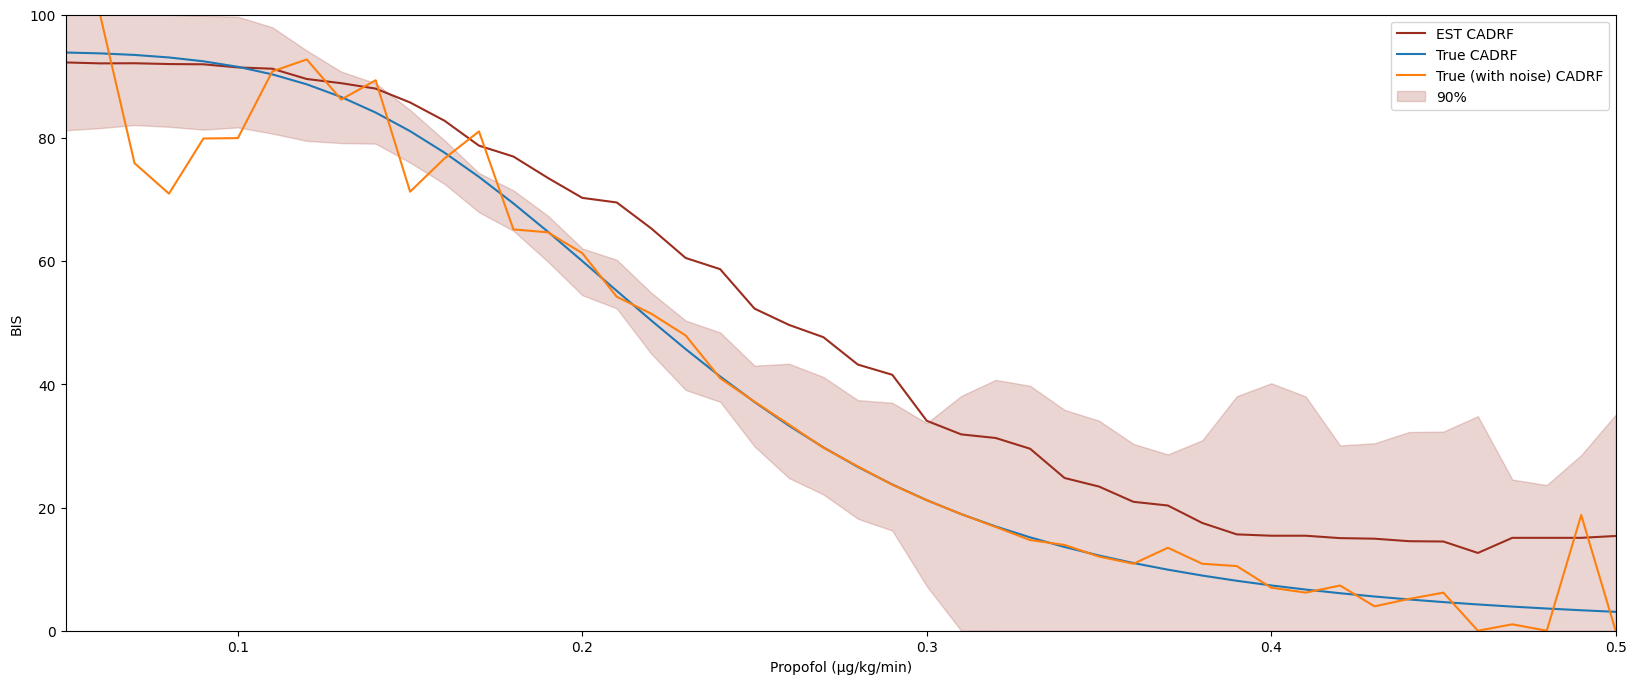

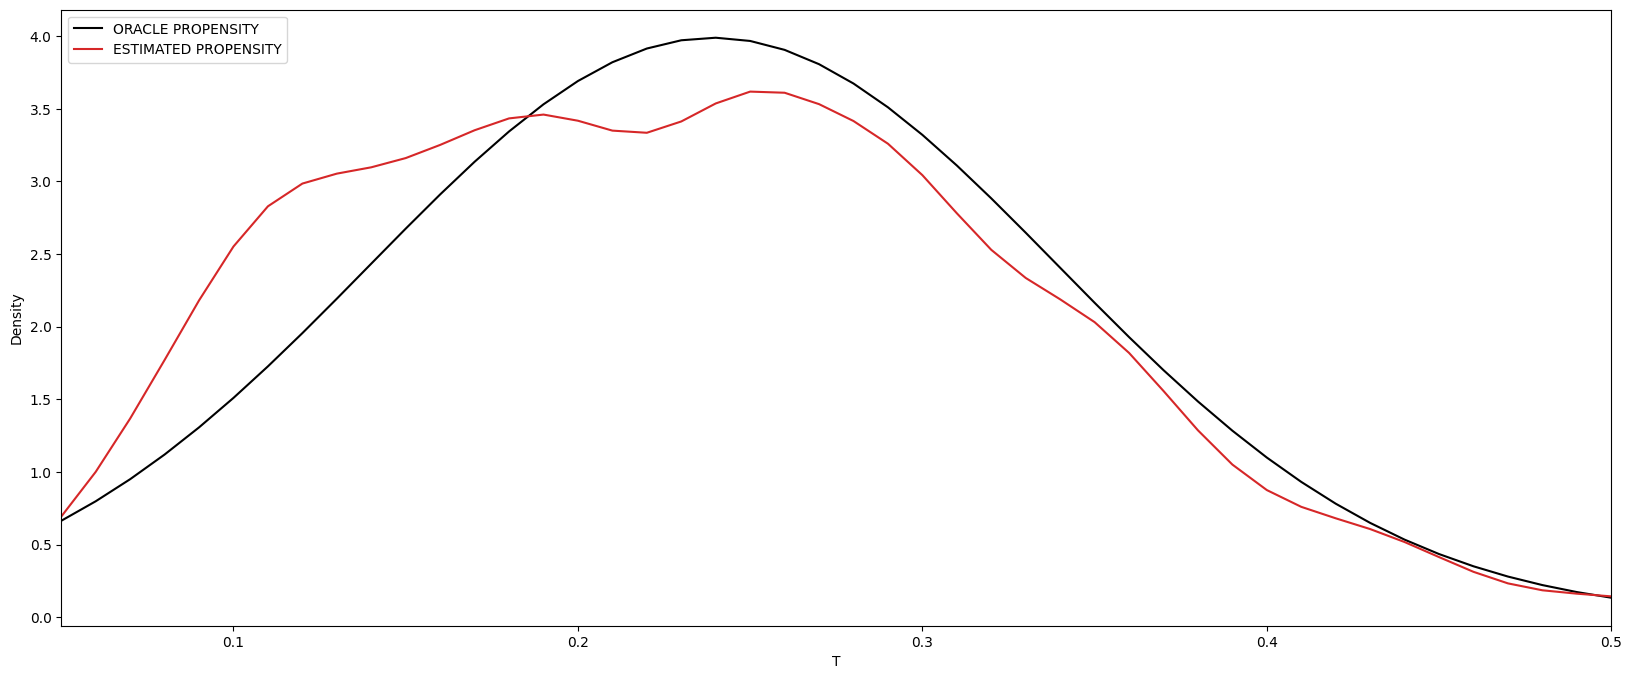

In [92]:
fig, ax = plt.subplots(1,1,figsize=(20,8))

# chosen_features = sample[features]

print(f"Current {treatment} = {test_df.iloc[chosen_idx][treatment]}")
print(f"Current {outcome} = {test_df.iloc[chosen_idx][outcome]}")

conditional_DRF_dataset = pd.DataFrame(
    np.hstack([np.tile(chosen_features,(len(treatment_range),1)),treatment_range.reshape(-1,1)]),
    columns=features+[treatment]
)

print(chosen_features)

wanted_cov = 0.90#cov_range[-1]


CATBOOST_lower_bounds_cov_list = []
CATBOOST_upper_bounds_cov_list = []

for selected_treatment in treatment_range:
    CATBOOST_lower_bounds_cov_list.append(CATBOOST_bounds_cov_dict[selected_treatment][wanted_cov][0,0])
    CATBOOST_upper_bounds_cov_list.append(CATBOOST_bounds_cov_dict[selected_treatment][wanted_cov][0,1])


# ax.plot([np.min(treatment_range),np.max(treatment_range)],[500,500],label="No ARDS",color="Grey")
# ax.plot([np.min(treatment_range),np.max(treatment_range)],[300,300],label="Mild",color="Green")
# ax.plot([np.min(treatment_range),np.max(treatment_range)],[200,200],label="Moderate",color="Yellow")
# ax.plot([np.min(treatment_range),np.max(treatment_range)],[100,100],label="Severe",color="Red")

#fill between color "#9B2D1F"
if not_oracle_test_bool:
    ax.plot(treatment_range, CPS_C_DRF_CATBOOST_base.learner.predict(conditional_DRF_dataset),label="EST CADRF",color="#9B2D1F")
else:
    ax.plot(treatment_range, ORACLE_WCDRF_local_prop.learner.predict(conditional_DRF_dataset),label="EST CADRF",color="#9B2D1F")
ax.plot(treatment_range,plot_df_single_sample["BISData"],label="True CADRF")
ax.plot(treatment_range,plot_df_single_sample["BISData_noise"],label="True (with noise) CADRF")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ax.fill_between(
        treatment_range,
        CATBOOST_lower_bounds_cov_list,
        CATBOOST_upper_bounds_cov_list,
    alpha=0.2,label="90%",color='#9B2D1F')

# ax.set_title(f"confidence = {wanted_cov}")
ax.set_xlim([np.min(treatment_range),np.max(treatment_range)])
ax.set_ylim([0,100])

ax.set_ylabel("BIS")
ax.set_xlabel("Propofol (µg/kg/min)")
# ax.scatter(X_AB_test[treatment],Y_AB_test.values,alpha=0.2,label="observations")
ax.legend()


plt.figure(figsize=(20,8))
plt.plot(treatment_range,amicas_datagenerator_object.get_treatment_mean(np.array([chosen_features.values])).pdf(treatment_range.reshape(-1,1)),label="ORACLE PROPENSITY", color="black")
plt.plot(treatment_range,np.exp(KernelDensity(kernel="gaussian", bandwidth=VAR_prop_bandwidth).fit((CPS_C_DRF_CATBOOST_base.propensityLearner.predict_cps(np.array([chosen_features.values]), return_cpds=True)[0, :, 0]).reshape(-1, 1)).score_samples(treatment_range.reshape(-1,1))),label="ESTIMATED PROPENSITY",color="C3")
plt.legend(loc="upper left")
plt.xlim([treatment_range[0],treatment_range[-1]])
plt.xlabel("T")
plt.ylabel("Density")
plt.plot()



# Experiments Loop

In [12]:
import copy

### SETTINGS

repeats = 50
cov_range = np.array([0.8, 0.9, 0.95]) 
VAR_prop_bandwidth = 0.02

cps_setting = False

repeat_final_dict_local_prop = {}
repeat_final_dict_global_prop = {}
repeat_final_dict_local_NO_prop = {}
repeat_final_dict_global_NO_prop = {}
# repeat_dict_GP = {}
repeat_dict_catboost_RMSE_Uncertainty = {}

repeat_final_dict_oracle_local_prop = {}
repeat_final_dict_oracle_global_prop = {}

treatment_range = np.array([])

amicas_datagenerator_object = amicas_datagenerator()

for repeat_numb in range(repeats):

    full_train_patient_ids, test_patient_ids = train_test_split(amicas_df.PatientID.unique(),  test_size=0.2, random_state=repeat_numb)

    synthetic_DRF_df_train_large = amicas_df[amicas_df.PatientID.isin(full_train_patient_ids)]
    synthetic_DRF_df_test = amicas_df[amicas_df.PatientID.isin(test_patient_ids)]

    BIS_counterfactual_df_test = BIS_counterfactual_df[BIS_counterfactual_df.PatientID.isin(test_patient_ids)]

    train_stay_ids, calibration_stay_ids = train_test_split(full_train_patient_ids,  test_size=0.33, random_state=repeat_numb)

    synthetic_DRF_df_train = synthetic_DRF_df_train_large[synthetic_DRF_df_train_large.PatientID.isin(train_stay_ids)]
    synthetic_DRF_df_calibrate = synthetic_DRF_df_train_large[synthetic_DRF_df_train_large.PatientID.isin(calibration_stay_ids)]

    # synthetic_DRF_df_train = amicas_df
    # synthetic_DRF_df_test = amicas_df
    # synthetic_DRF_df_calibrate = amicas_df

    OraclePropensityWrapperObject = OraclePropensityWrapper(amicas_datagenerator_object)

    # GP fit model
    # gpr = GaussianProcessRegressor(kernel=RBF()+W(),normalize_y=True)
    # gpr.fit(synthetic_DRF_df_train[features+[treatment]], synthetic_DRF_df_train[outcome].values)

    # CATBOOST RMSE UNCERTAINTY
    RMSE_UNCERT_CATBOOST_model = CatBoostRegressor(verbose=False,iterations=1000,use_best_model=True,loss_function="RMSEWithUncertainty")
    RMSE_UNCERT_CATBOOST_model.fit(synthetic_DRF_df_train[features+[treatment]], synthetic_DRF_df_train[outcome].values,eval_set=(synthetic_DRF_df_calibrate[features+[treatment]],synthetic_DRF_df_calibrate[outcome]))
    

    # CATBOOST base models
    CATBOOST_propensity_model = CatBoostRegressor(verbose=False,iterations=1000,use_best_model=True)
    C_DRF_CATBOOST_base = CatBoostRegressor(verbose=False,iterations=1000,use_best_model=True)

    #standard 
    CPS_C_DRF_CATBOOST_base = DRFWrapRegressor(CATBOOST_propensity_model, C_DRF_CATBOOST_base)
    CPS_C_DRF_CATBOOST_base.fit(synthetic_DRF_df_train[features+[treatment]], synthetic_DRF_df_train[outcome].values,eval_set=(synthetic_DRF_df_calibrate[features+[treatment]],synthetic_DRF_df_calibrate[outcome]))

    CPS_C_DRF_CATBOOST_base.fit_propensity(synthetic_DRF_df_train[features], synthetic_DRF_df_train[treatment].values,eval_set=(synthetic_DRF_df_calibrate[features],synthetic_DRF_df_calibrate[treatment]))
    CPS_C_DRF_CATBOOST_base.calibrate_propensity(synthetic_DRF_df_calibrate[features], synthetic_DRF_df_calibrate[treatment].values)

    #oracle standard
    CPS_C_DRF_CATBOOST_ORACLE = DRFWrapRegressor(OraclePropensityWrapperObject, CatBoostRegressor(verbose=False,iterations=1000,use_best_model=True), oracle_propensity=True)
    CPS_C_DRF_CATBOOST_ORACLE.fit(synthetic_DRF_df_train[features+[treatment]], synthetic_DRF_df_train[outcome].values,eval_set=(synthetic_DRF_df_calibrate[features+[treatment]],synthetic_DRF_df_calibrate[outcome]))


    WCDRF_local_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_base)
    WCDRF_global_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_base)


    WCDRF_local_NO_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_base)
    WCDRF_global_NO_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_base)

    ORACLE_WCDRF_local_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_ORACLE)
    ORACLE_WCDRF_global_prop = copy.deepcopy(CPS_C_DRF_CATBOOST_ORACLE)


    Coverages_df = pd.DataFrame(columns=["method","treatment","effective_sample_rate","confidence","emp_coverage"])


    plot_W_min = 0.05
    plot_W_max = 0.51

    
    #making sure the treatments are the same across experiments
    if len(treatment_range) < 1:
        treatment_range = np.arange(plot_W_min,plot_W_max,0.01)

    cal_df = synthetic_DRF_df_calibrate.copy(deep=True)
    test_df = synthetic_DRF_df_test.copy(deep=True)


    WCDRF_local_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)
    WCDRF_global_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)
    WCDRF_local_NO_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000, use_propensity = False)
    WCDRF_global_NO_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000, use_propensity = False)

    ORACLE_WCDRF_local_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)
    ORACLE_WCDRF_global_prop.prepare_calibration(cal_df[features].values, cal_df[treatment].values, multiplier = 0.2, density_bandwidth=VAR_prop_bandwidth, batch_size_limit = 5000)

            
    WCDRF_global_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, cps=cps_setting, use_propensity = True, local_conditional_mode=False)
    WCDRF_global_NO_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, cps=cps_setting, use_propensity = False, local_conditional_mode=False)

    ORACLE_WCDRF_global_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, cps=cps_setting, use_propensity = True, local_conditional_mode=False)
    
    WCDRF_local_prop_bounds_cov_dict = {}
    WCDRF_local_NO_prop_bounds_cov_dict = {}
    WCDRF_global_prop_bounds_cov_dict = {}
    WCDRF_global_NO_prop_bounds_cov_dict = {}
    dict_catboost_RMSE_Uncertainty = {}
    # dict_GP = {}
    
    ORACLE_WCDRF_local_prop_bounds_cov_dict = {}
    ORACLE_WCDRF_global_prop_bounds_cov_dict = {}


    for d_t in treatment_range:
        d_t = np.round(d_t,2)

        print(f"\r propofol = {d_t} - \t repeat {repeat_numb+1}/{repeats}",end="")

        int_coverage_df_calibrate = test_df[features+[treatment]].copy(deep=True)
        int_coverage_df_calibrate[treatment]=d_t

        test_true_obs_df = test_df[["PatientID","Time","Propofol"]].copy(deep=True)
        test_true_obs_df[treatment] = d_t
        test_true_obs_df = test_true_obs_df.merge(BIS_counterfactual_df_test,how="left",on=["PatientID","Time","Propofol"])

        ### GET TRUE OBSERVATION
        true_observation_mean = test_true_obs_df["BISData"].values

        true_observation_noise = amicas_datagenerator_object.add_noise(int_coverage_df_calibrate[features].values,int_coverage_df_calibrate[treatment].values)

        if np.shape(true_observation_mean) == np.shape(true_observation_noise):
            true_observation = true_observation_mean + true_observation_noise

            true_observation = np.max([np.repeat(0,len(true_observation)),np.min([np.repeat(100,len(true_observation)),true_observation],axis=0)],axis=0)
        else:
            raise Exception("True observation shape error")
        
        # GP_predict_mean, GP_predict_std = gpr.predict(int_coverage_df_calibrate[features+[treatment]], return_std = True)
        CB_uncertainty_preds = RMSE_UNCERT_CATBOOST_model.predict(int_coverage_df_calibrate[features+[treatment]])
        CB_uncertainty_mean_preds, CB_uncertainty_var_preds = CB_uncertainty_preds[:,0], CB_uncertainty_preds[:, 1]
        
        local_WCDRF_local_prop_bounds_cov_dict = {}
        local_WCDRF_local_NO_prop_bounds_cov_dict = {}
        local_WCDRF_global_prop_bounds_cov_dict = {}
        local_WCDRF_global_NO_prop_bounds_cov_dict = {}
        local_dict_catboost_RMSE_Uncertainty = {}
        # local_dict_GP = {}
        local_ORACLE_WCDRF_local_prop_bounds_cov_dict = {}
        local_ORACLE_WCDRF_global_prop_bounds_cov_dict = {}
        
        local_WCDRF_local_prop_bounds_cov_dict["true_obs"] = true_observation
        local_WCDRF_local_NO_prop_bounds_cov_dict["true_obs"] = true_observation
        local_WCDRF_global_prop_bounds_cov_dict["true_obs"] = true_observation
        local_WCDRF_global_NO_prop_bounds_cov_dict["true_obs"] = true_observation
        local_dict_catboost_RMSE_Uncertainty["true_obs"] = true_observation
        # local_dict_GP["true_obs"] = true_observation

        local_ORACLE_WCDRF_local_prop_bounds_cov_dict["true_obs"] = true_observation
        local_ORACLE_WCDRF_global_prop_bounds_cov_dict["true_obs"] = true_observation

        ### CALIBRATE LOCAL PROPENSITY MODELS
        
        WCDRF_local_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, target_treatment=d_t, cps=cps_setting, use_propensity = True)

        WCDRF_local_NO_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, target_treatment=d_t, cps=cps_setting, use_propensity = False)

        ORACLE_WCDRF_local_prop.calibrate(cal_df[features+[treatment]], cal_df[outcome].values, cal_df[treatment].values, target_treatment=d_t, cps=cps_setting, use_propensity = True)


        # to avoid an error
        WCDRF_global_prop.target_treatment = d_t
        ORACLE_WCDRF_global_prop.target_treatment = d_t
        

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            WCDRF_local_prop_bounds_matrix = WCDRF_local_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )

            WCDRF_local_NO_prop_bounds_matrix = WCDRF_local_NO_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )
            
            WCDRF_global_prop_bounds_matrix = WCDRF_global_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )
            
            
            WCDRF_global_NO_prop_bounds_matrix = WCDRF_global_NO_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )
            
            ORACLE_WCDRF_global_prop_bounds_matrix = ORACLE_WCDRF_global_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )
            
            ORACLE_WCDRF_local_prop_bounds_matrix = ORACLE_WCDRF_local_prop.predict_multi_int(
                                X=int_coverage_df_calibrate[features+[treatment]].values,
                                y_min=0,
                                y_max=100,
                                confidence_range=cov_range
                                )

        for cov, cov_idx in zip(cov_range,range(len(cov_range))):
            CB_uncertainty_lower_PI = CB_uncertainty_mean_preds - np.sqrt(CB_uncertainty_var_preds)*erfinv(cov)*sqrt(2)
            CB_uncertainty_upper_PI = CB_uncertainty_mean_preds + np.sqrt(CB_uncertainty_var_preds)*erfinv(cov)*sqrt(2)
            CB_uncertainty_bounds = np.hstack((CB_uncertainty_lower_PI.reshape(-1,1),CB_uncertainty_upper_PI.reshape(-1,1)))

            # GP_lower_PI = GP_predict_mean - GP_predict_std*erfinv(cov)*sqrt(2)
            # GP_upper_PI = GP_predict_mean + GP_predict_std*erfinv(cov)*sqrt(2)
            # GP_bounds = np.hstack((GP_lower_PI.reshape(-1,1),GP_upper_PI.reshape(-1,1)))

            local_WCDRF_local_prop_bounds_cov_dict[cov] = WCDRF_local_prop_bounds_matrix[cov_idx, :, :]
            local_WCDRF_local_NO_prop_bounds_cov_dict[cov] = WCDRF_local_NO_prop_bounds_matrix[cov_idx, :, :]
            local_WCDRF_global_prop_bounds_cov_dict[cov] = WCDRF_global_prop_bounds_matrix[cov_idx, :, :]
            local_WCDRF_global_NO_prop_bounds_cov_dict[cov] = WCDRF_global_NO_prop_bounds_matrix[cov_idx, :, :]
            local_dict_catboost_RMSE_Uncertainty[cov] = CB_uncertainty_bounds
            # local_dict_GP[cov] = GP_bounds

            local_ORACLE_WCDRF_local_prop_bounds_cov_dict[cov] = ORACLE_WCDRF_local_prop_bounds_matrix[cov_idx, :, :]
            local_ORACLE_WCDRF_global_prop_bounds_cov_dict[cov] = ORACLE_WCDRF_global_prop_bounds_matrix[cov_idx, :, :]

        WCDRF_local_prop_bounds_cov_dict[d_t] = local_WCDRF_local_prop_bounds_cov_dict
        WCDRF_local_NO_prop_bounds_cov_dict[d_t] = local_WCDRF_local_NO_prop_bounds_cov_dict
        WCDRF_global_prop_bounds_cov_dict[d_t] = local_WCDRF_global_prop_bounds_cov_dict
        WCDRF_global_NO_prop_bounds_cov_dict[d_t] = local_WCDRF_global_NO_prop_bounds_cov_dict
        dict_catboost_RMSE_Uncertainty[d_t] = local_dict_catboost_RMSE_Uncertainty
        # dict_GP[d_t] = local_dict_GP
        
        ORACLE_WCDRF_local_prop_bounds_cov_dict[d_t] = local_ORACLE_WCDRF_local_prop_bounds_cov_dict
        ORACLE_WCDRF_global_prop_bounds_cov_dict[d_t] = local_ORACLE_WCDRF_global_prop_bounds_cov_dict


    repeat_final_dict_local_prop[repeat_numb] = WCDRF_local_prop_bounds_cov_dict
    repeat_final_dict_local_NO_prop[repeat_numb] = WCDRF_local_NO_prop_bounds_cov_dict
    repeat_final_dict_global_prop[repeat_numb] = WCDRF_global_prop_bounds_cov_dict
    repeat_final_dict_global_NO_prop[repeat_numb] = WCDRF_global_NO_prop_bounds_cov_dict
    repeat_dict_catboost_RMSE_Uncertainty[repeat_numb] = dict_catboost_RMSE_Uncertainty
    # repeat_dict_GP[repeat_numb] = dict_GP
    
    repeat_final_dict_oracle_local_prop[repeat_numb] = ORACLE_WCDRF_local_prop_bounds_cov_dict
    repeat_final_dict_oracle_global_prop[repeat_numb] = ORACLE_WCDRF_global_prop_bounds_cov_dict



with open('results/WCDRF_local_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_local_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('results/WCDRF_global_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_global_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('results/WCDRF_local_NO_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_local_NO_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('results/WCDRF_global_NO_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_global_NO_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('results/Catboost_uncertainty_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_dict_catboost_RMSE_Uncertainty, handle, protocol=pickle.HIGHEST_PROTOCOL)
# with open('results/GP_AMICAS.pickle', 'wb') as handle:
#     pickle.dump(repeat_dict_GP, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('results/ORACLE_local_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_oracle_local_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('results/ORACLE_global_prop_AMICAS.pickle', 'wb') as handle:
    pickle.dump(repeat_final_dict_oracle_global_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)                         


 propofol = 0.5 - 	 repeat 50/500

# Results Processing and figures

In [4]:
cov_range = np.array([0.8, 0.9, 0.95]) 
REPEATS = 50

methods_list = [
    "WCDRF_LOCAL_PROP",
    "WCDRF_GLOBAL_PROP",
    "WCDRF_LOCAL_NO_PROP",
    "WCDRF_GLOBAL_NO_PROP",
    "CATBOOST_UNCERTAINTY",
    # "GP", 
    "ORACLE_LOCAL_PROP",
    "ORACLE_GLOBAL_PROP",
]

In [5]:
with open('results/WCDRF_local_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_local_prop = pickle.load(handle)
with open('results/WCDRF_global_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_global_prop = pickle.load(handle)
with open('results/WCDRF_local_NO_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_local_NO_prop = pickle.load(handle)
with open('results/WCDRF_global_NO_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_global_NO_prop = pickle.load(handle)
# with open('results/GP_AMICAS.pickle', 'rb') as handle:
#     repeat_dict_GP = pickle.load(handle)
with open('results/Catboost_uncertainty_AMICAS.pickle', 'rb') as handle:
    repeat_dict_catboost_RMSE_Uncertainty = pickle.load(handle)
with open('results/ORACLE_local_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_oracle_local_prop = pickle.load(handle)
with open('results/ORACLE_global_prop_AMICAS.pickle', 'rb') as handle:
    repeat_final_dict_oracle_global_prop = pickle.load(handle)

In [6]:
WCDRF_LOCAL_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])
WCDRF_GLOBAL_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])
WCDRF_LOCAL_NO_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])
WCDRF_GLOBAL_NO_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])
CATBOOST_UNCERTAINTY_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])
GP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])

ORACLE_LOCAL_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])

ORACLE_GLOBAL_PROP_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])

all_results_df = pd.DataFrame()#columns=["method", "repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","RMSE"])

for loop_dict, loop_method in zip([
    repeat_final_dict_local_prop, 
    repeat_final_dict_global_prop, 
    repeat_final_dict_local_NO_prop, 
    repeat_final_dict_global_NO_prop, 
    repeat_dict_catboost_RMSE_Uncertainty, 
    repeat_final_dict_oracle_local_prop,
    repeat_final_dict_oracle_global_prop,
    ],methods_list):
    for repeat_numb in tqdm(range(REPEATS)):
        for d_t in loop_dict[repeat_numb].keys():
            true_observation = loop_dict[repeat_numb][d_t]["true_obs"]


            for cov in cov_range:
                if loop_method in ["CATBOOST_UNCERTAINTY","WCDRF_GLOBAL_NO_PROP"]:
                    mean_prediction_bounds = loop_dict[repeat_numb][d_t][cov]
                    mean_prediction = (mean_prediction_bounds[:,1] + mean_prediction_bounds[:,0])/2
                else:
                    mean_prediction_bounds = repeat_final_dict_global_NO_prop[repeat_numb][d_t][cov]
                    mean_prediction = (mean_prediction_bounds[:,1] + mean_prediction_bounds[:,0])/2

                RMSE_current = np.sqrt(np.mean((mean_prediction - true_observation)**2))

                methods_bounds = loop_dict[repeat_numb][d_t][cov]
                coverage_emp = np.mean(((true_observation >= methods_bounds[:,0]) * (true_observation <= methods_bounds[:,1])))
                mean_sharpness = np.mean(methods_bounds[:,1] - methods_bounds[:,0])
                min_sharpness = np.min(methods_bounds[:,1] - methods_bounds[:,0])
                q25_sharpness = np.quantile(methods_bounds[:,1] - methods_bounds[:,0], 0.25)
                median_sharpness = np.median(methods_bounds[:,1] - methods_bounds[:,0])

                if loop_method == "WCDRF_LOCAL_PROP":
                    WCDRF_LOCAL_PROP_results_df = pd.concat([WCDRF_LOCAL_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                elif loop_method == "WCDRF_GLOBAL_PROP":
                    WCDRF_GLOBAL_PROP_results_df = pd.concat([WCDRF_GLOBAL_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                elif loop_method == "WCDRF_LOCAL_NO_PROP":
                    WCDRF_LOCAL_NO_PROP_results_df = pd.concat([WCDRF_LOCAL_NO_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                elif loop_method == "WCDRF_GLOBAL_NO_PROP":
                    WCDRF_GLOBAL_NO_PROP_results_df = pd.concat([WCDRF_GLOBAL_NO_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                elif loop_method == "CATBOOST_UNCERTAINTY":
                    CATBOOST_UNCERTAINTY_results_df = pd.concat([CATBOOST_UNCERTAINTY_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                # elif loop_method == "GP":
                #     GP_results_df = pd.concat([GP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                
                elif loop_method == "ORACLE_LOCAL_PROP":
                    ORACLE_LOCAL_PROP_results_df = pd.concat([ORACLE_LOCAL_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                elif loop_method == "ORACLE_GLOBAL_PROP":
                    ORACLE_GLOBAL_PROP_results_df = pd.concat([ORACLE_GLOBAL_PROP_results_df, pd.DataFrame([np.array([loop_method, repeat_numb, d_t, cov, coverage_emp,mean_sharpness,min_sharpness,q25_sharpness,median_sharpness,RMSE_current])],columns=["method","repeat_numb","treatment","confidence","emp_coverage","mean_sharpness","min_sharpness","q25_sharpness","median_sharpness","RMSE"])])
                
print("CONCATENATING")
all_results_df = pd.concat([all_results_df, WCDRF_LOCAL_PROP_results_df])
all_results_df = pd.concat([all_results_df, WCDRF_GLOBAL_PROP_results_df])
all_results_df = pd.concat([all_results_df, WCDRF_LOCAL_NO_PROP_results_df])
all_results_df = pd.concat([all_results_df, WCDRF_GLOBAL_NO_PROP_results_df])
all_results_df = pd.concat([all_results_df, CATBOOST_UNCERTAINTY_results_df])
# all_results_df = pd.concat([all_results_df, GP_results_df])

all_results_df = pd.concat([all_results_df, ORACLE_LOCAL_PROP_results_df])
all_results_df = pd.concat([all_results_df, ORACLE_GLOBAL_PROP_results_df])

100%|██████████| 50/50 [00:08<00:00,  6.02it/s]

CONCATENATING


In [7]:
all_results_df["treatment"] = all_results_df["treatment"].values.astype(np.float64)
all_results_df["emp_coverage"] = all_results_df["emp_coverage"].values.astype(np.float64)
all_results_df["confidence"] = all_results_df["confidence"].values.astype(np.float64)
all_results_df["repeat_numb"] = all_results_df["repeat_numb"].values.astype(np.float64)
all_results_df["mean_sharpness"] = all_results_df["mean_sharpness"].values.astype(np.float64)
all_results_df["min_sharpness"] = all_results_df["min_sharpness"].values.astype(np.float64)
all_results_df["q25_sharpness"] = all_results_df["q25_sharpness"].values.astype(np.float64)
all_results_df["median_sharpness"] = all_results_df["median_sharpness"].values.astype(np.float64)
all_results_df["RMSE"] = all_results_df["RMSE"].values.astype(np.float64)

all_results_df.to_csv("results/all_results_df_AMICAS.csv",index=False)

# Results plotting

In [94]:
all_results_df = pd.read_csv("results/all_results_df_AMICAS.csv")

In [95]:
allowed_models_visualization = ['WCDRF_LOCAL_PROP', 'WCDRF_GLOBAL_PROP', 'WCDRF_LOCAL_NO_PROP',
       'WCDRF_GLOBAL_NO_PROP', 'CATBOOST_UNCERTAINTY', 
       # 'GP',
       'ORACLE_LOCAL_PROP', 'ORACLE_GLOBAL_PROP',
       ]
all_results_df = all_results_df[all_results_df.method.isin(allowed_models_visualization)]

all_results_df.loc[all_results_df.method=="WCDRF_GLOBAL_NO_PROP","method"] = "CP"
all_results_df.loc[all_results_df.method=="WCDRF_LOCAL_NO_PROP","method"] = "WCP Local"
all_results_df.loc[all_results_df.method=="WCDRF_GLOBAL_PROP","method"] = "WCP Global Propensity"
all_results_df.loc[all_results_df.method=="WCDRF_LOCAL_PROP","method"] = "WCP Local Propensity"
all_results_df.loc[all_results_df.method=="ORACLE_GLOBAL_PROP","method"] = "WCP Global Oracle"
all_results_df.loc[all_results_df.method=="ORACLE_LOCAL_PROP","method"] = "WCP Local Oracle"
# all_results_df.loc[all_results_df.method=="GP","method"] = "Gaussian Process"
all_results_df.loc[all_results_df.method=="CATBOOST_UNCERTAINTY","method"] = "Catboost with uncertainty"

all_results_df = all_results_df.rename(columns={"emp_coverage":"Empirical Coverage"})
all_results_df = all_results_df.rename(columns={"method":"Method"})

In [ ]:
for method in['CP','Catboost with uncertainty', 'Gaussian Process']:
    mean_plot_values_RMSE = all_results_df[(all_results_df.Method == method) & (all_results_df.confidence == 0.9)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","RMSE","treatment"]].groupby(["Method","treatment"]).mean().reset_index()["RMSE"].values
    std_plot_values_RMSE = all_results_df[(all_results_df.Method == method) & (all_results_df.confidence == 0.9)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","RMSE","treatment"]].groupby(["Method","treatment"]).std().reset_index()["RMSE"].values

    if method == "CP":
        plt.plot(all_results_df.treatment.unique(), mean_plot_values_RMSE,label=method+" and WCP")
    else:
        plt.plot(all_results_df.treatment.unique(), mean_plot_values_RMSE,label=method)
    plt.fill_between(all_results_df.treatment.unique(), mean_plot_values_RMSE - std_plot_values_RMSE, mean_plot_values_RMSE + std_plot_values_RMSE, alpha=0.25)
    # plt.plot(all_results_df.treatment.unique(), all_results_df[(all_results_df.Method == method) & (all_results_df.confidence == 0.9)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","RMSE","treatment"]].groupby(["Method","treatment"]).std().reset_index()))
    plt.ylabel("RMSE")
    plt.xlabel("Treatment")
    plt.legend()

    # plt.savefig("figures/RMSE_plot_source_"+str(EXPERIMENT_SOURCE)+"_scenario_"+str(EXPERIMENT_SCENARIO)+".pdf",bbox_inches="tight")

In [ ]:
import seaborn as sns

for plot_treatment in all_results_df["treatment"].unique():
    required_cov = 0.9
    repeat_numb_test = all_results_df[(all_results_df.treatment == plot_treatment)&(all_results_df.confidence == required_cov)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","RMSE"]].groupby(["Method","repeat_numb"]).mean().reset_index()

    fig, axs = plt.subplots(1, 1, figsize=(8,6))
    
    sns.boxplot(
        repeat_numb_test, x="RMSE", y="Method", hue="Method", ax=axs #width=.6, palette="vlag"
    )
    axs.set_title(f"treatment = {plot_treatment}")

    # fig.savefig("figures/coverage_barplot_cov_"+str(int(required_cov*100))+"_source_"+str(EXPERIMENT_SOURCE)+"_scenario_"+str(EXPERIMENT_SCENARIO)+".pdf",bbox_inches="tight")

    plt.show()

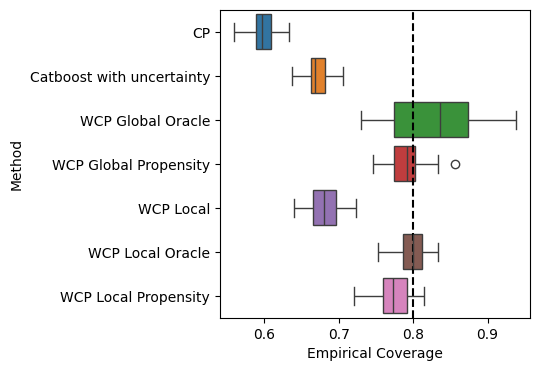

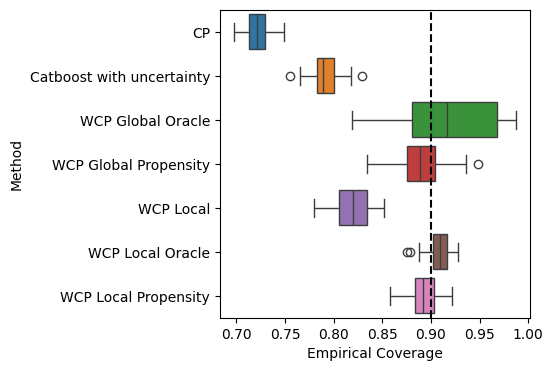

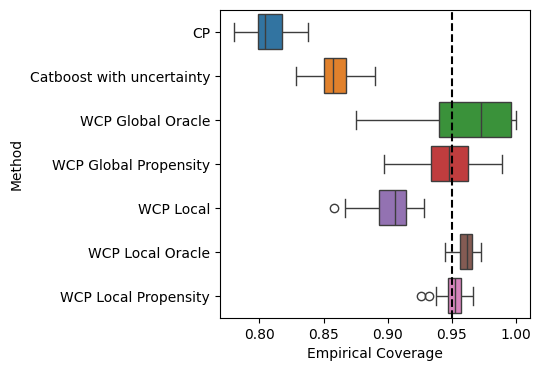

In [ ]:
import seaborn as sns

for required_cov in [0.8,0.9,0.95]:
    repeat_numb_test = all_results_df[(all_results_df.confidence == required_cov)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","Empirical Coverage"]].groupby(["Method","repeat_numb"]).mean().reset_index()

    fig, axs = plt.subplots(1, 1, figsize=(4,4))
    
    sns.boxplot(
        repeat_numb_test, x="Empirical Coverage", y="Method", hue="Method", ax=axs 
    )
    axs.axvline(x = required_cov, color="black", linestyle="--")
    # axs.set_title(f"cov = {required_cov}")

    # fig.savefig("figures/coverage_barplot_cov_"+str(int(required_cov*100))+"_source_"+str(EXPERIMENT_SOURCE)+"_scenario_"+str(EXPERIMENT_SCENARIO)+".pdf",bbox_inches="tight")


    plt.show()

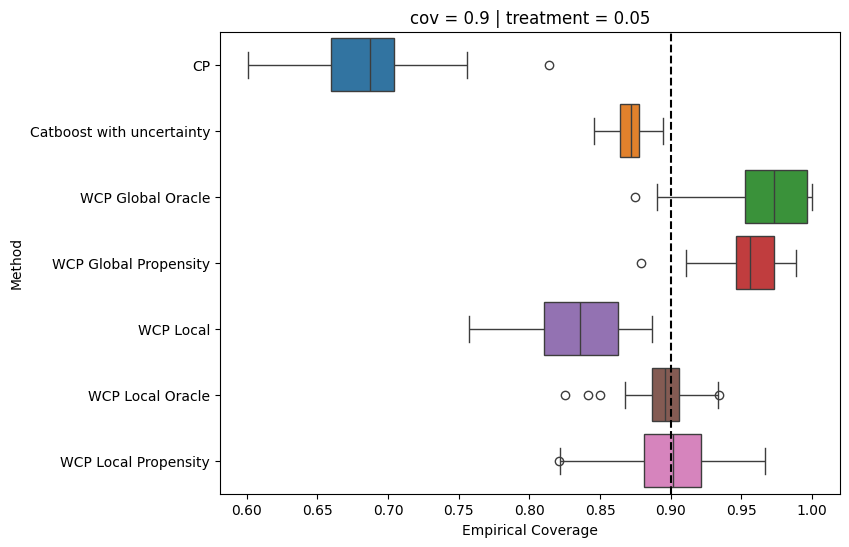

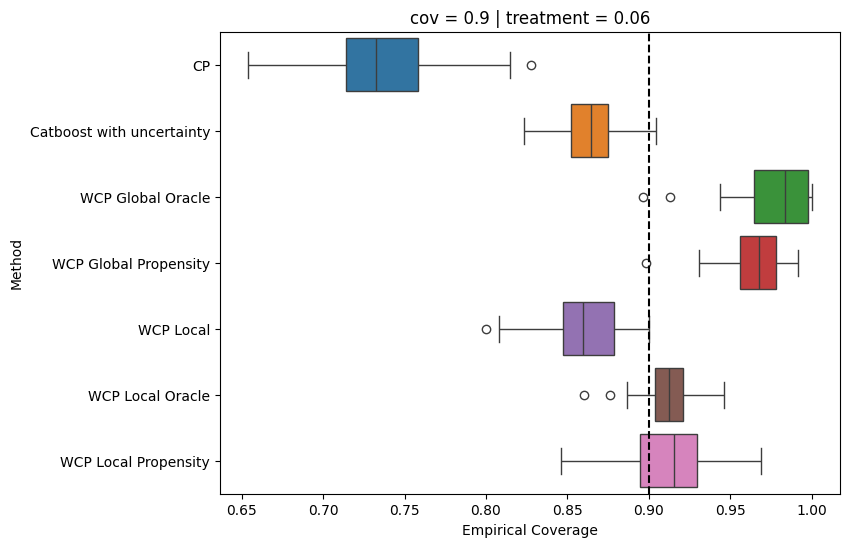

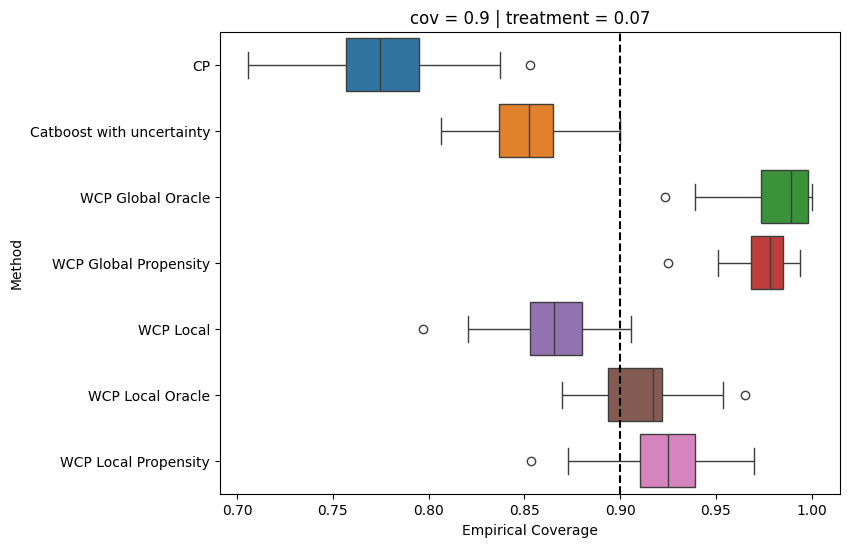

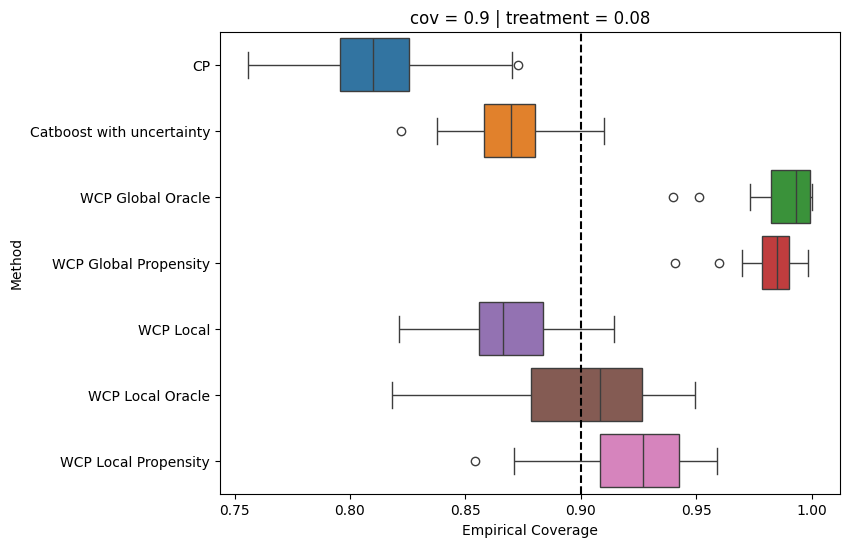

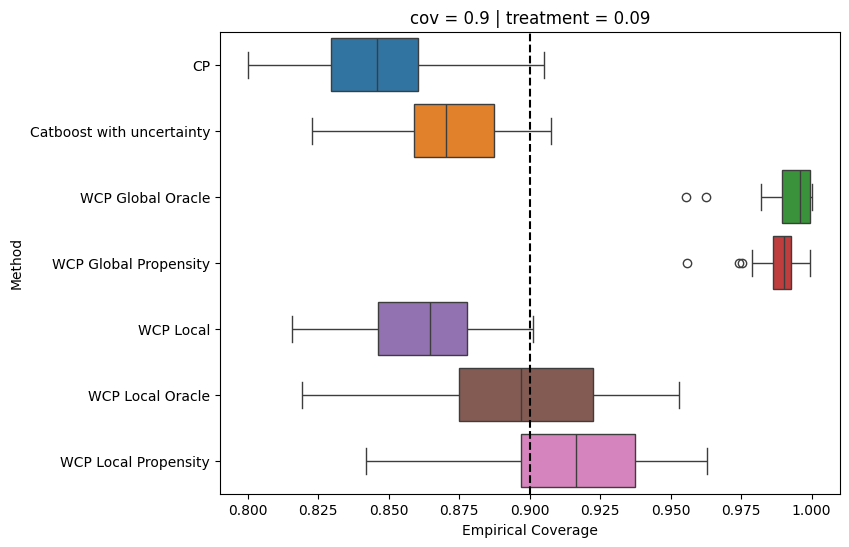

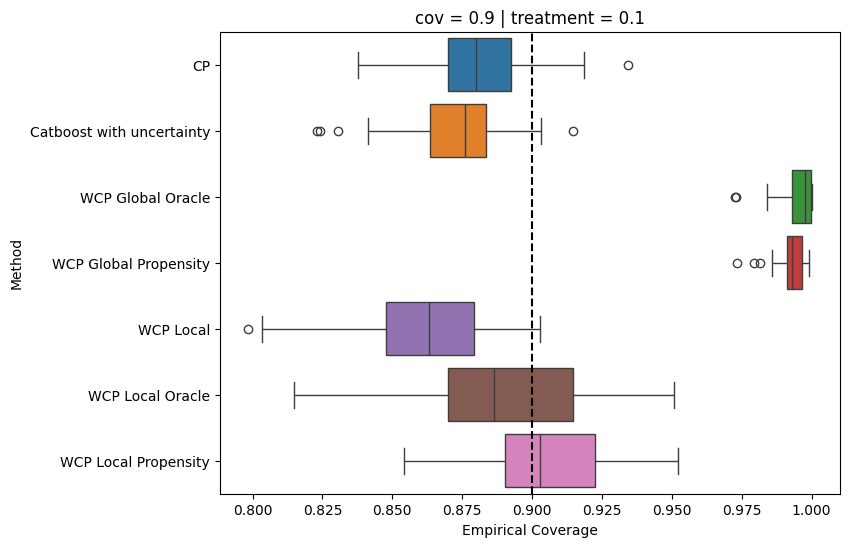

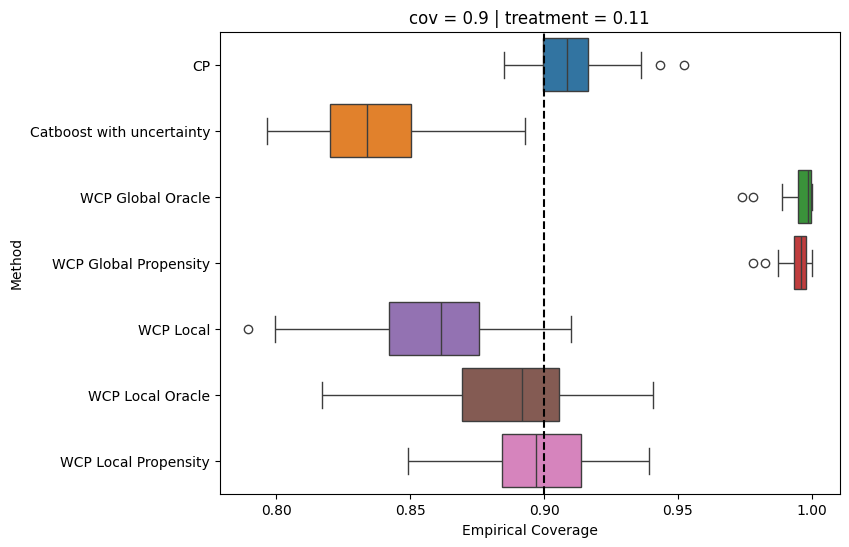

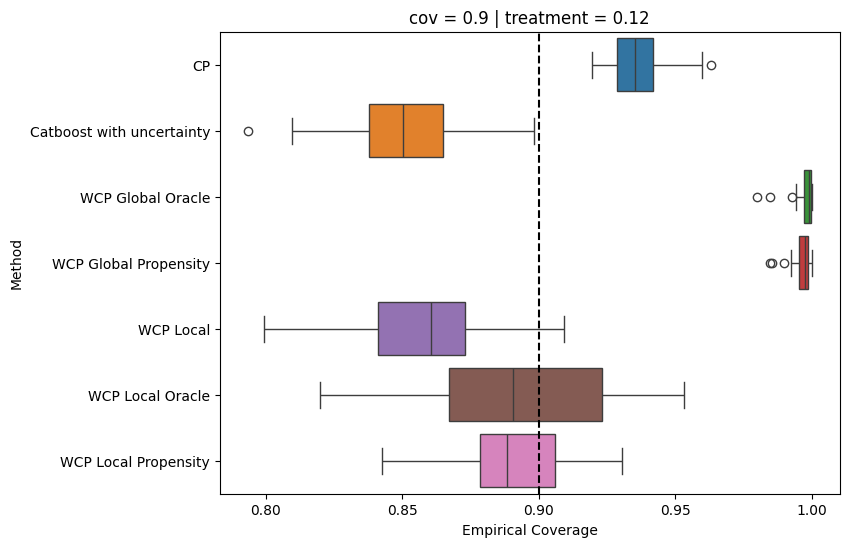

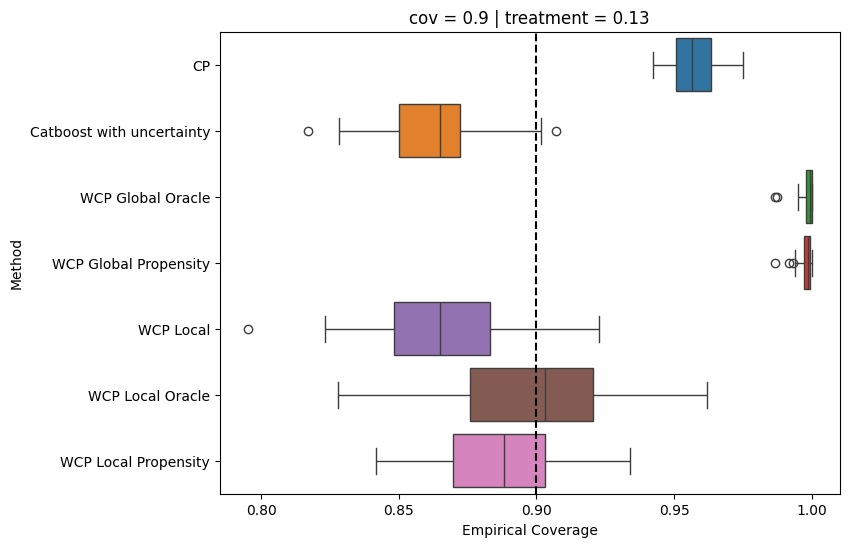

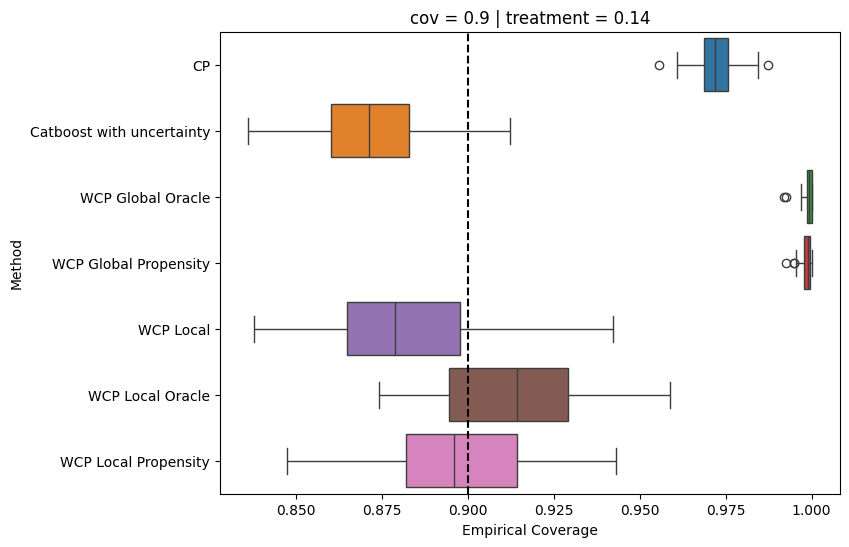

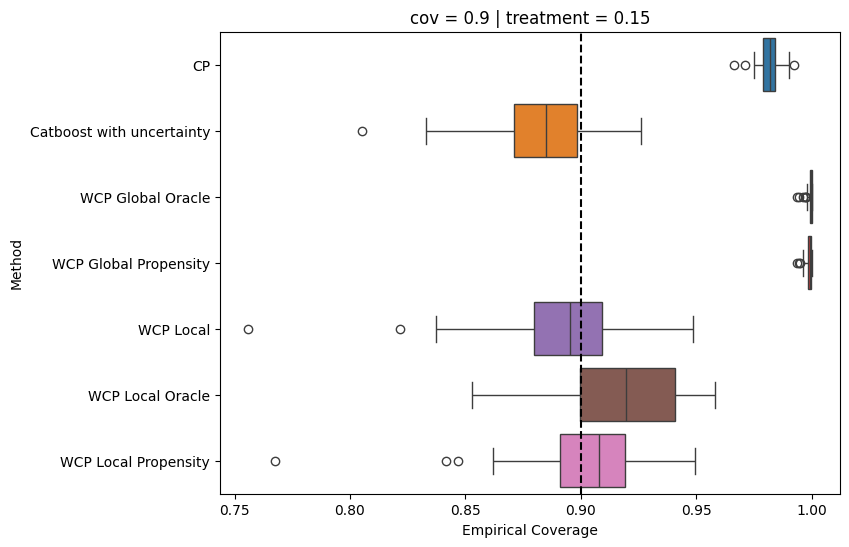

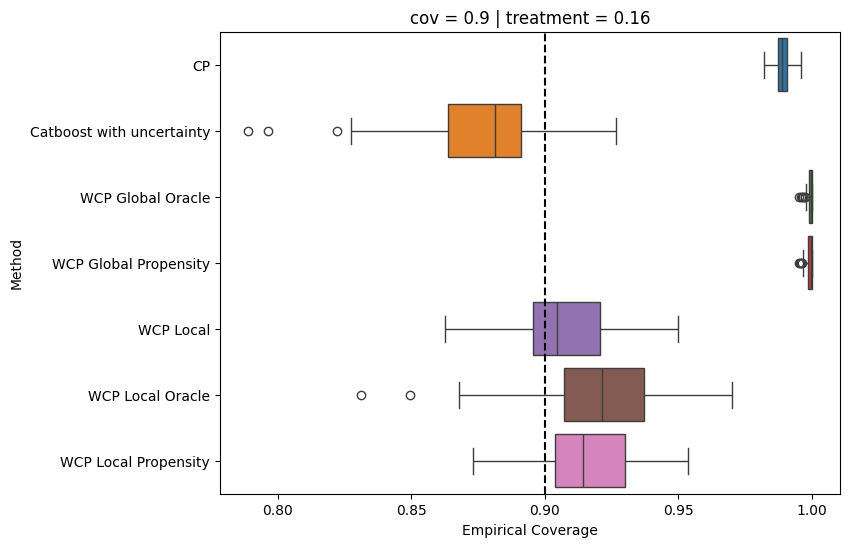

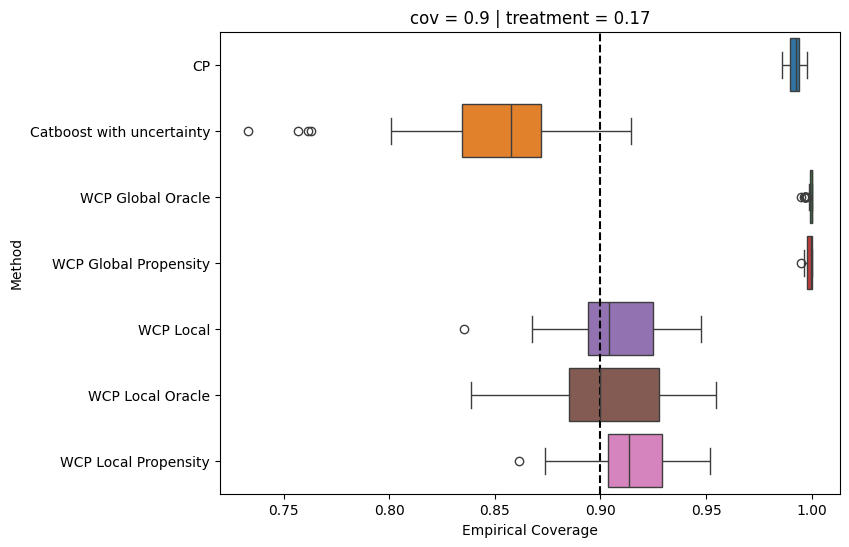

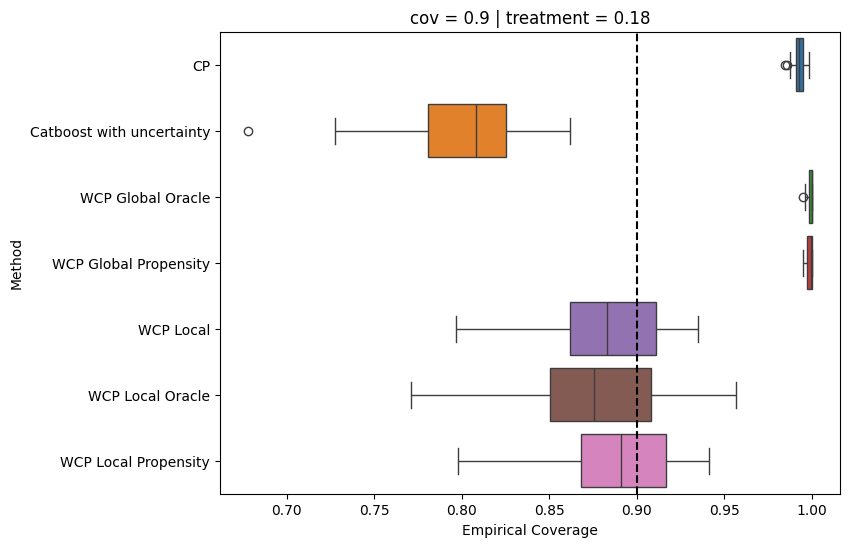

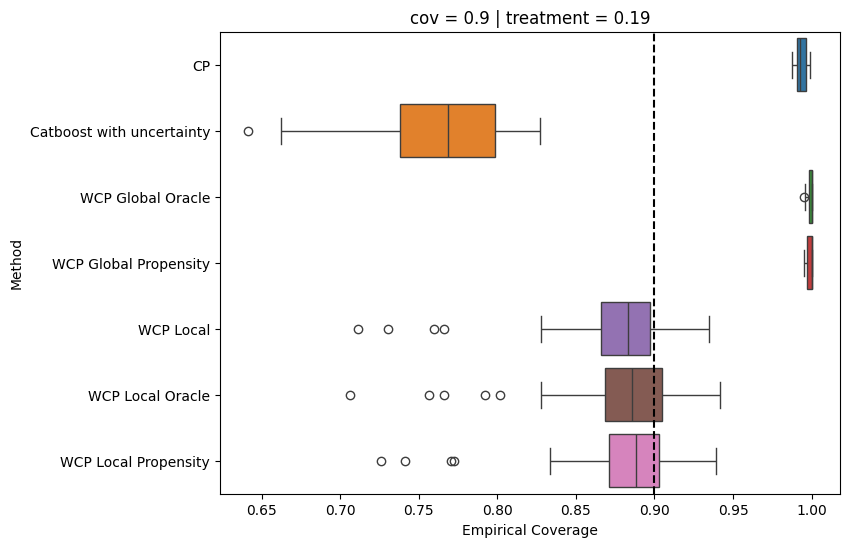

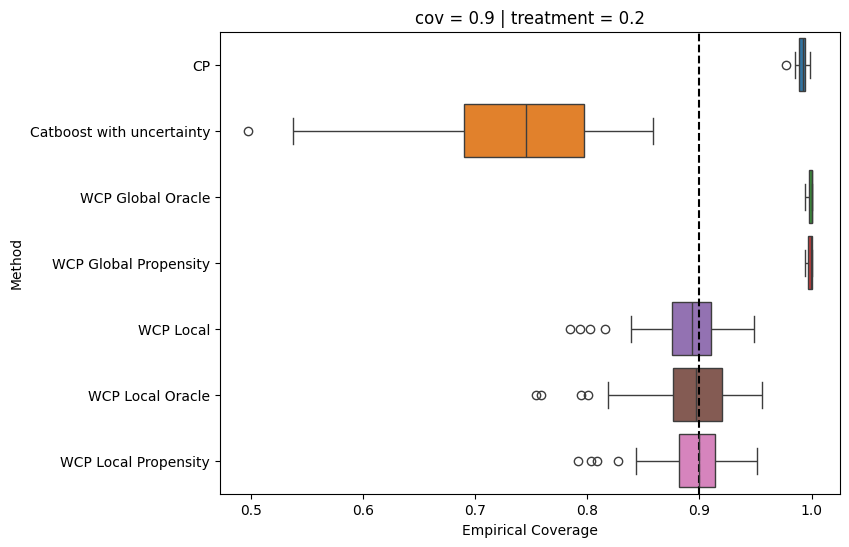

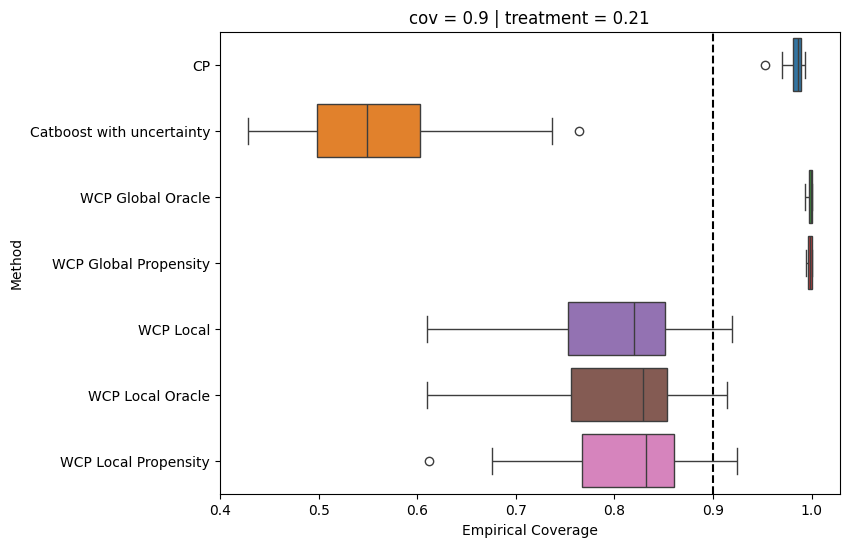

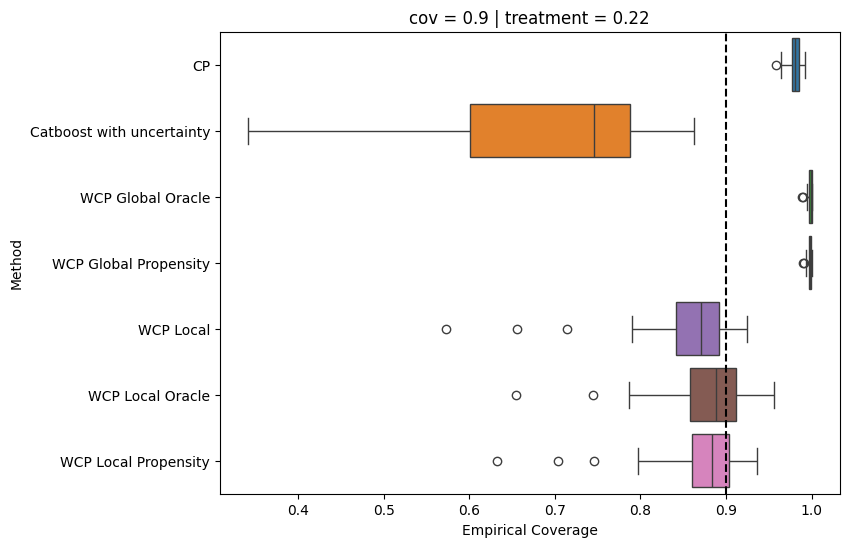

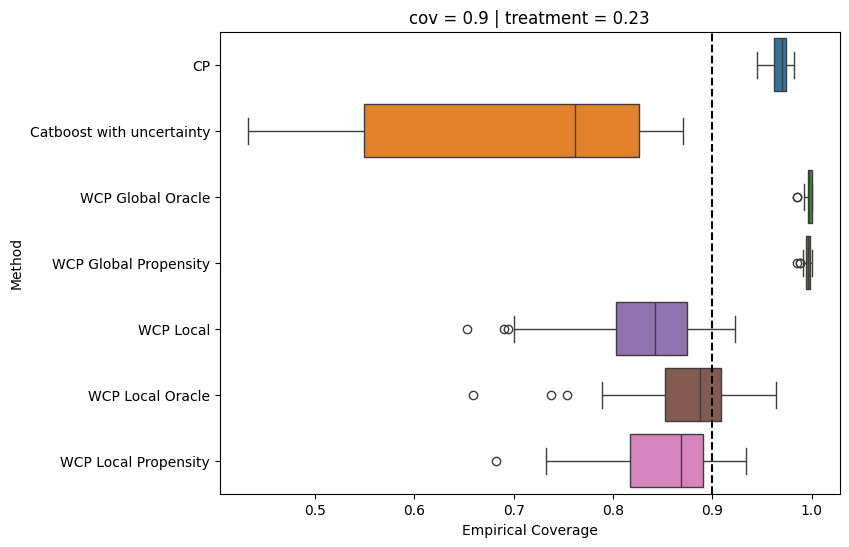

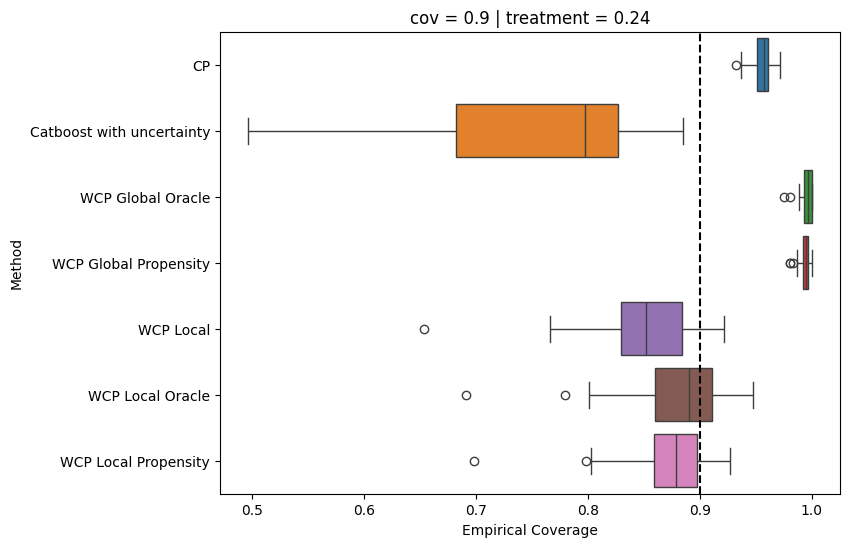

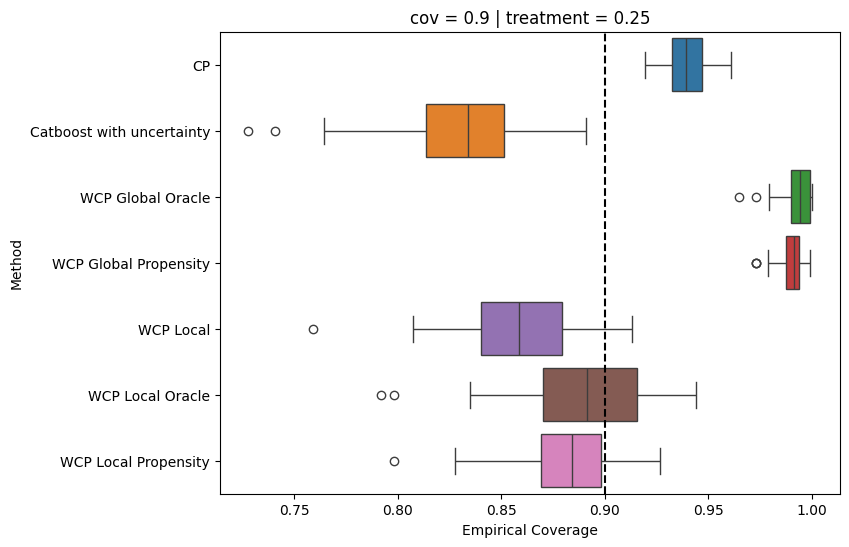

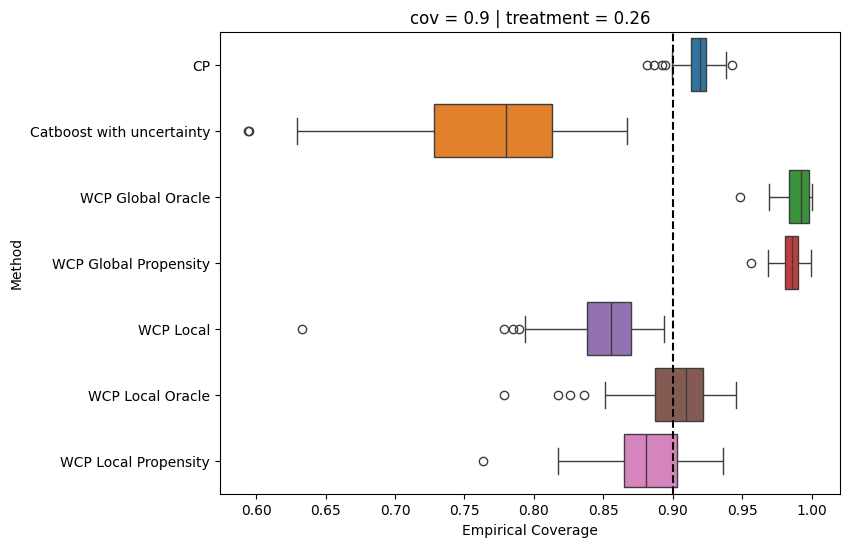

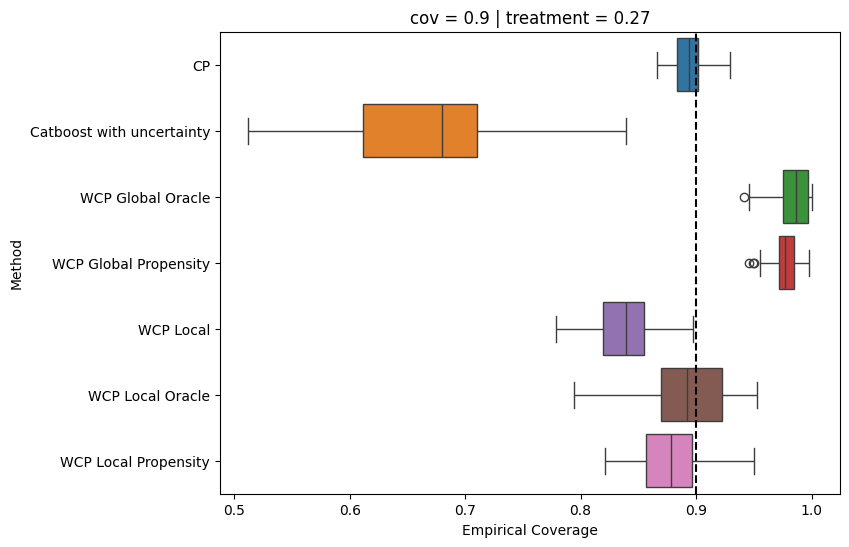

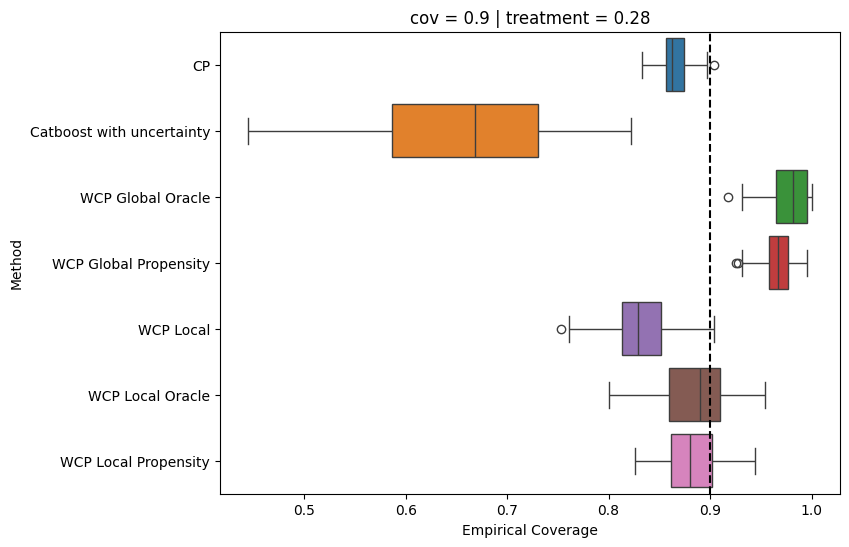

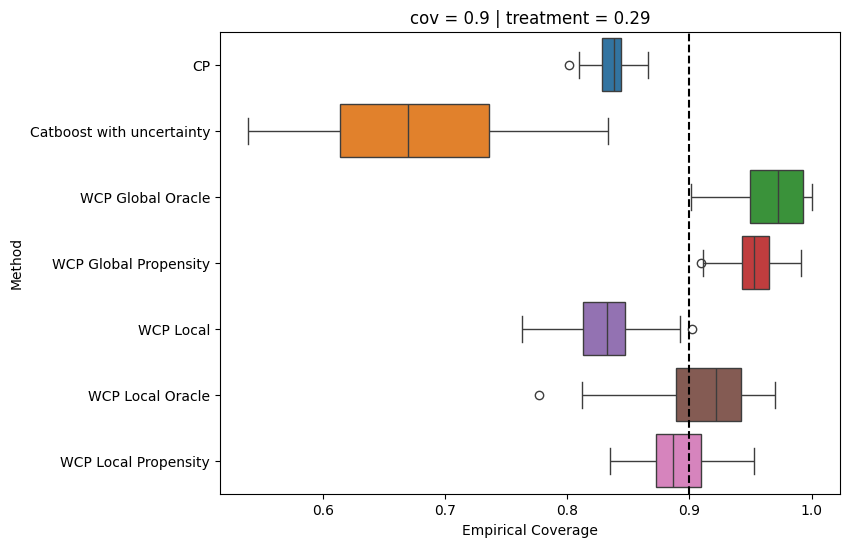

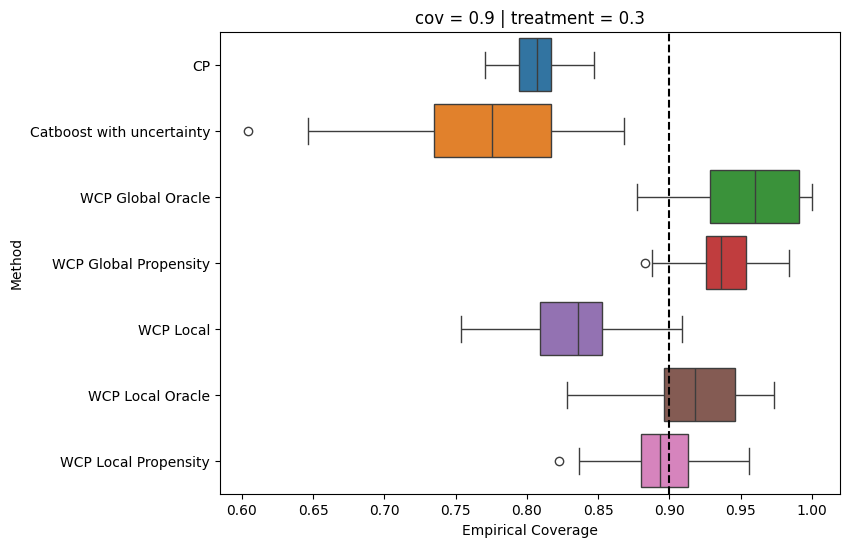

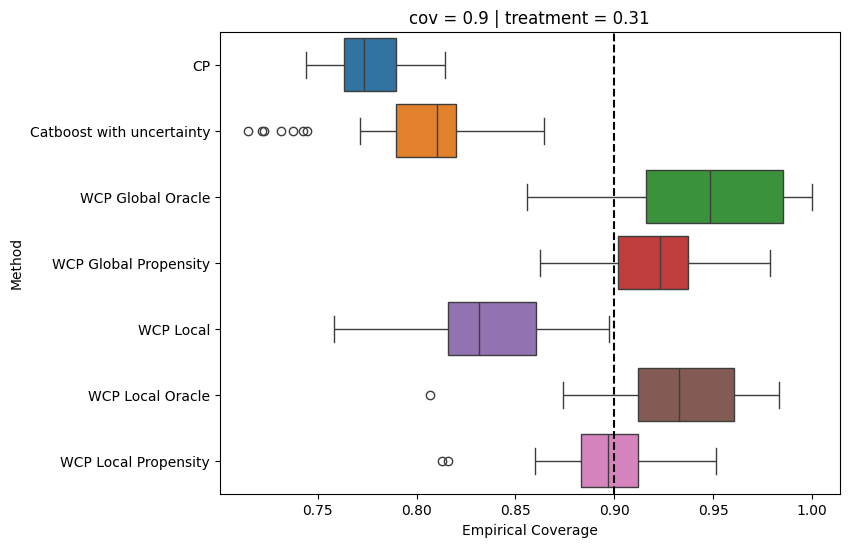

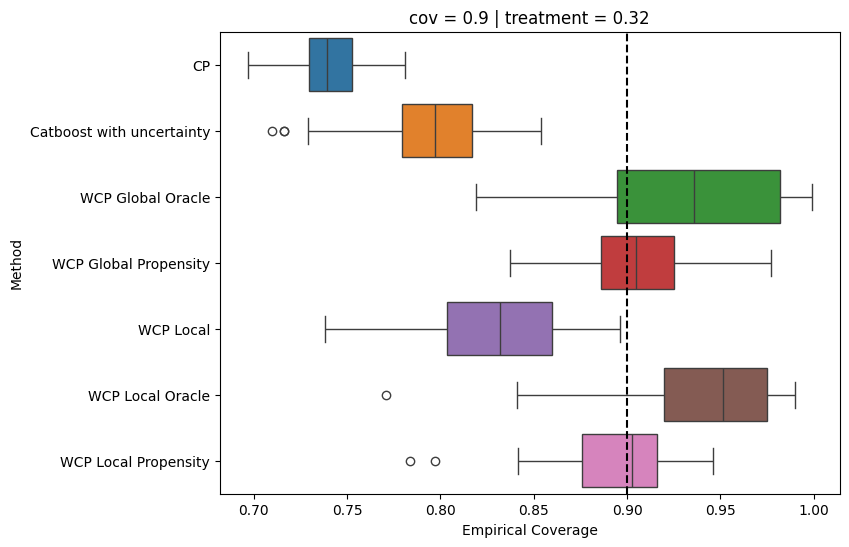

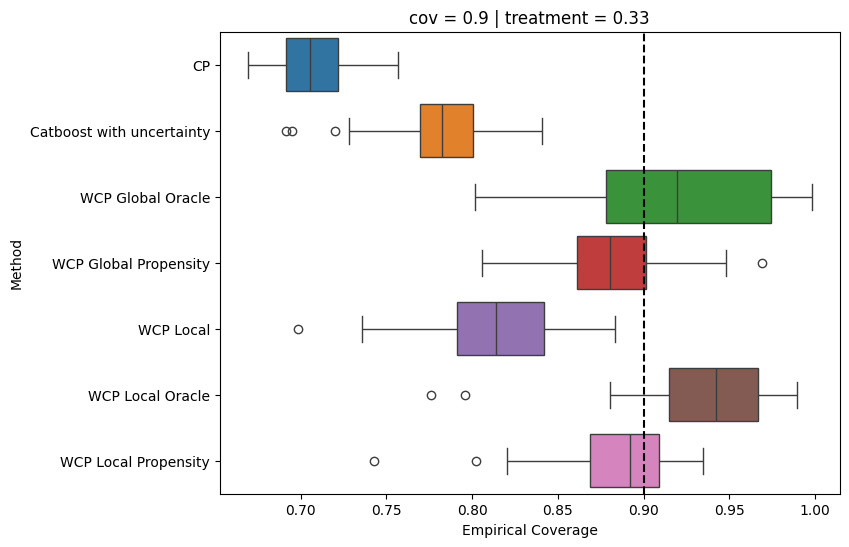

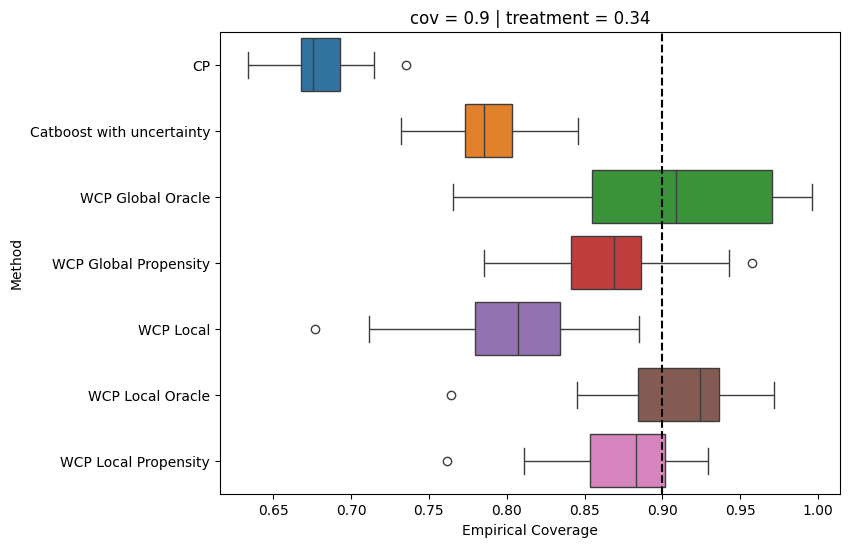

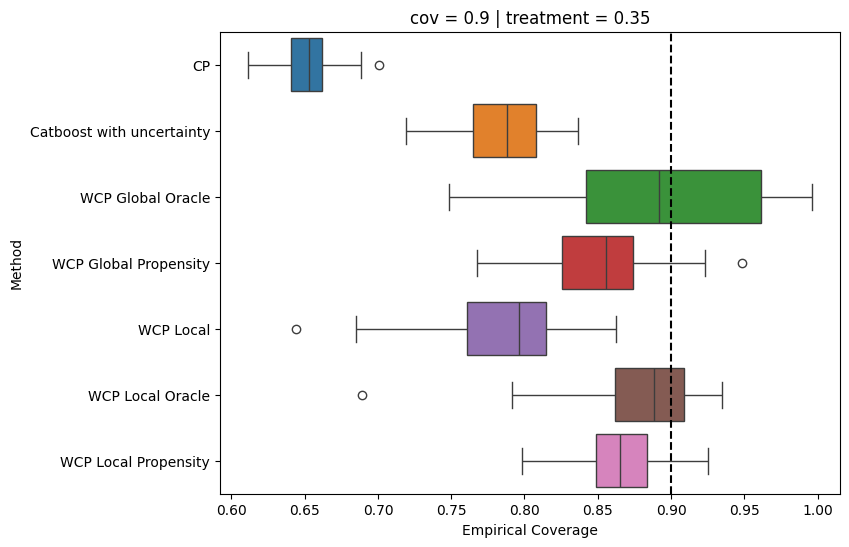

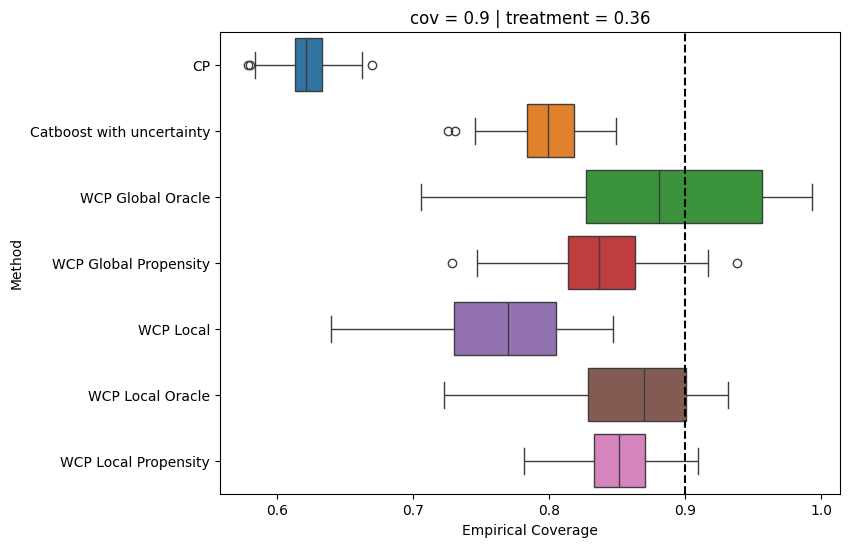

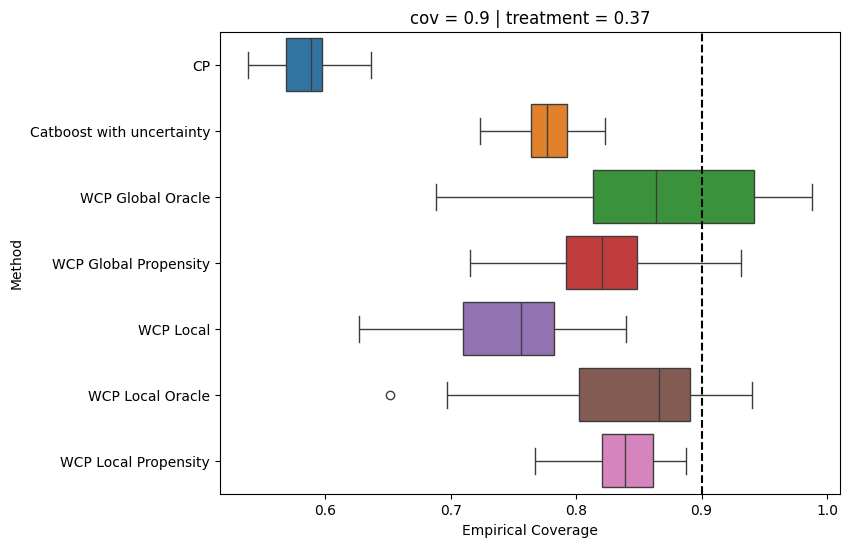

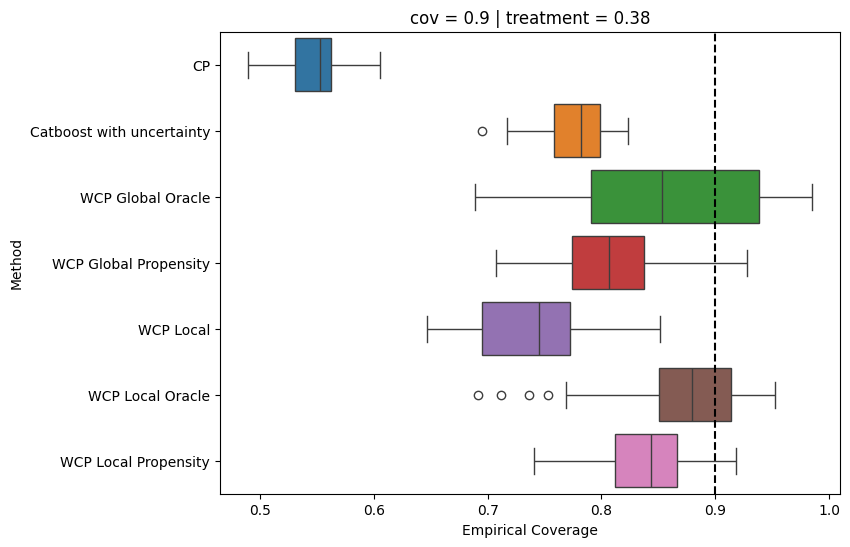

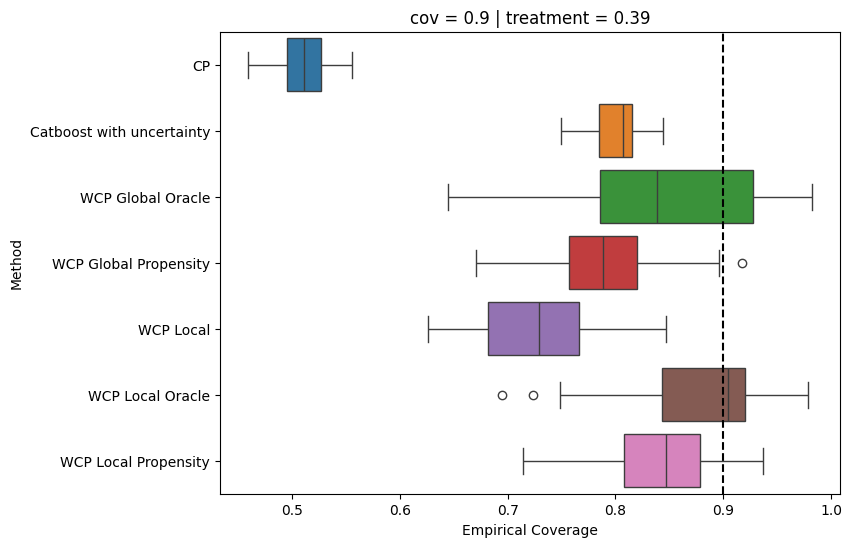

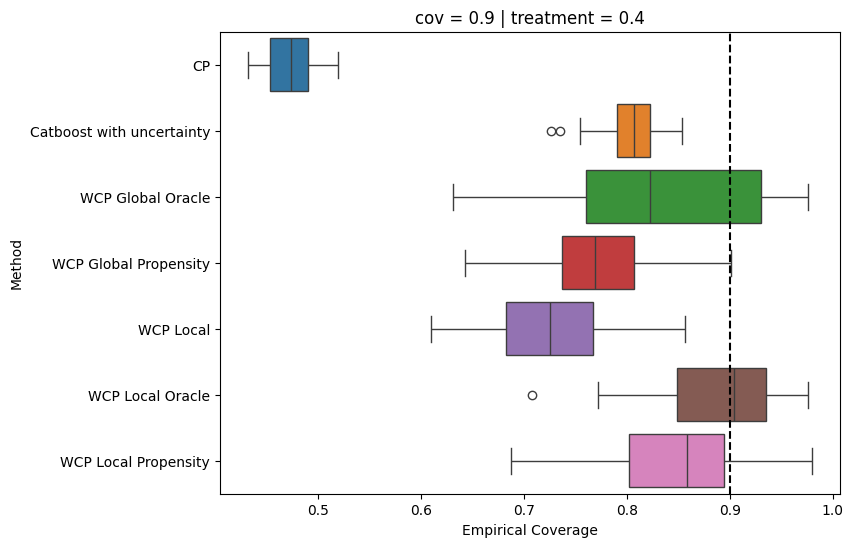

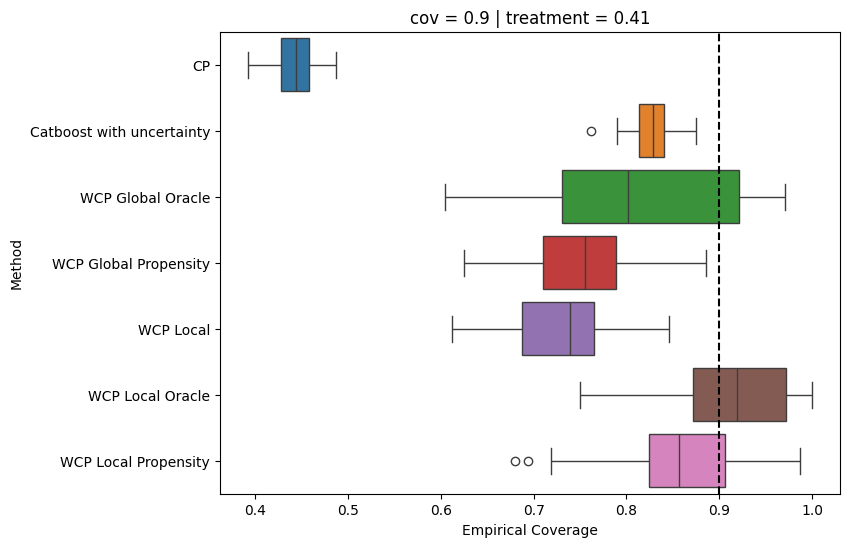

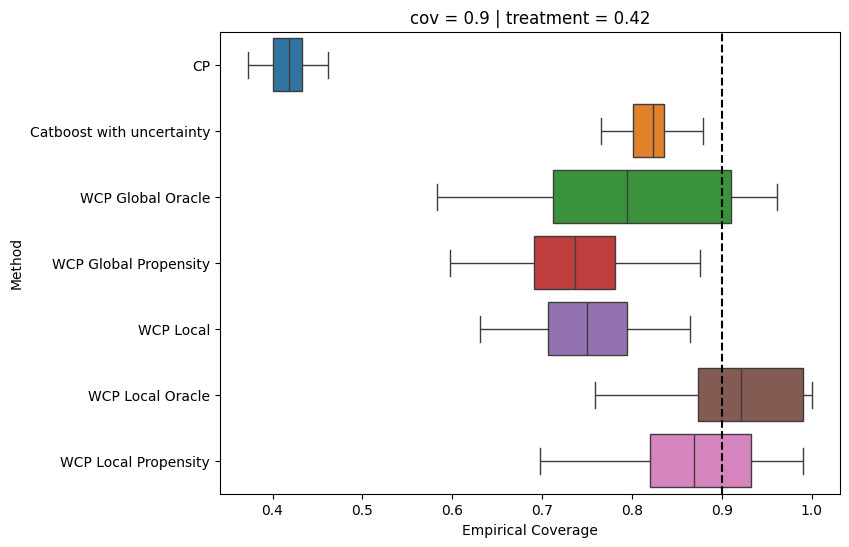

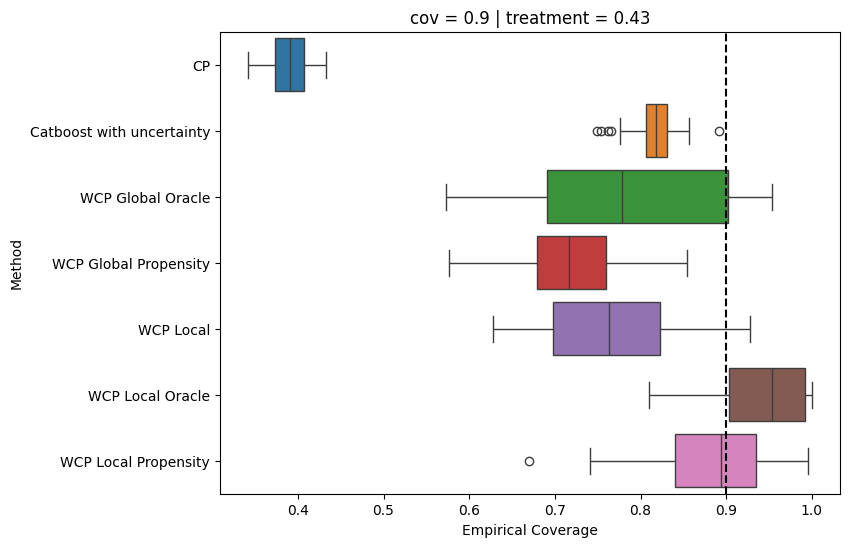

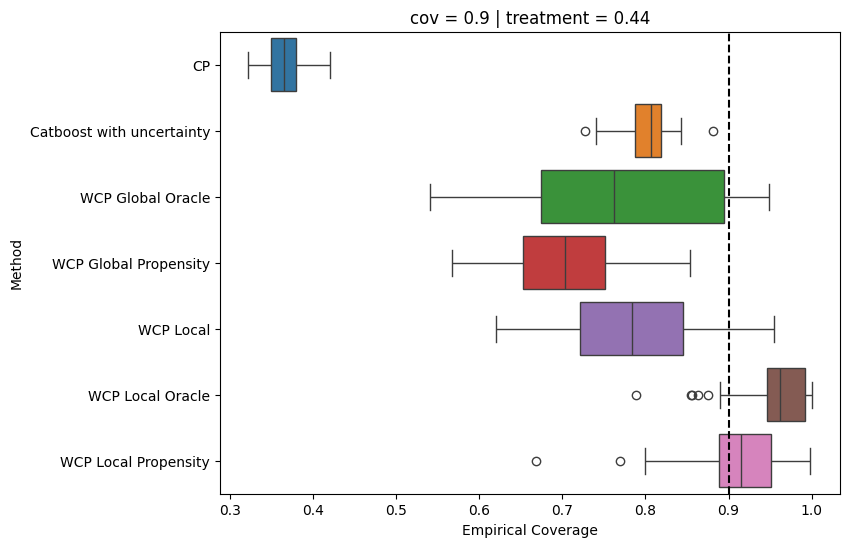

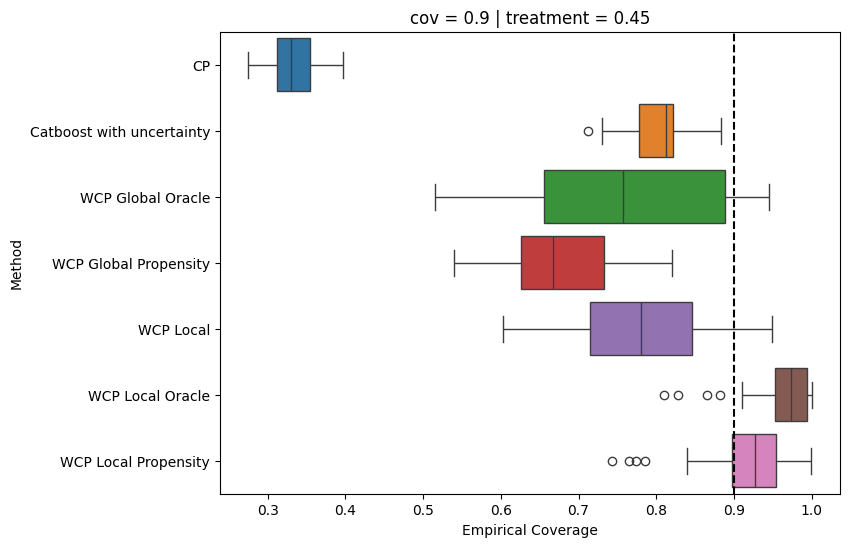

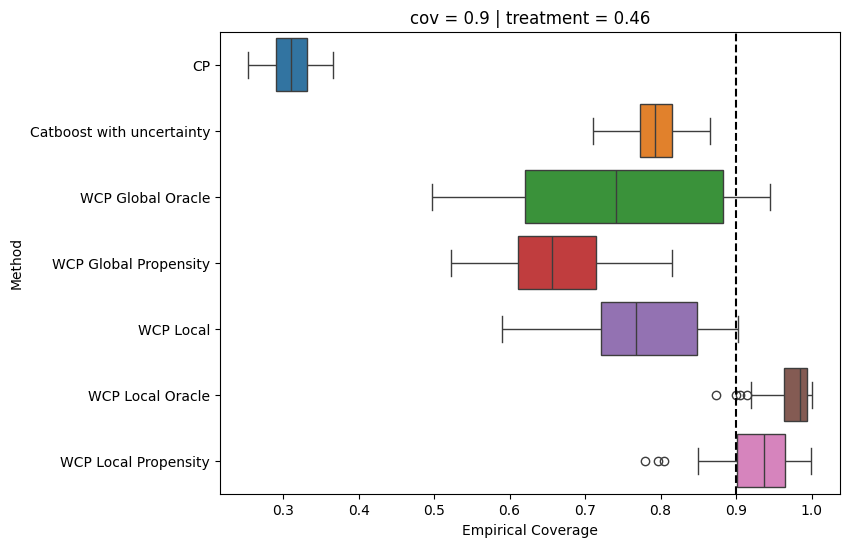

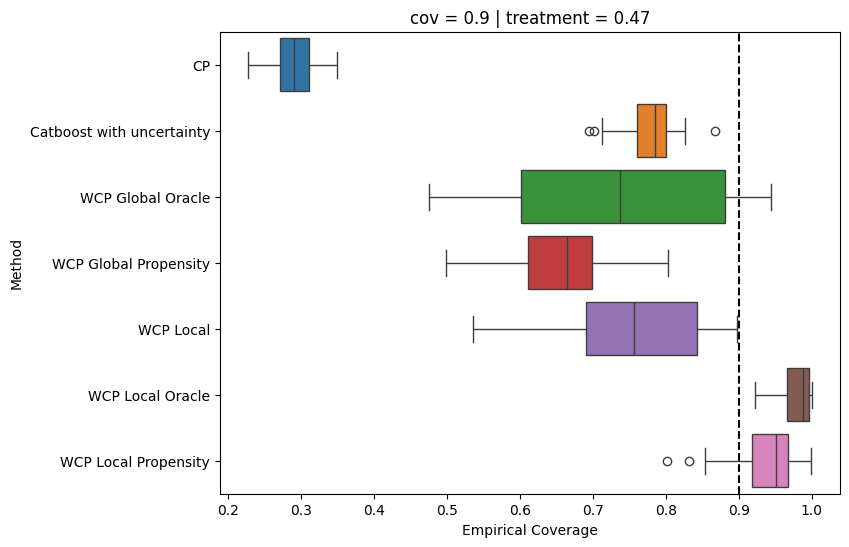

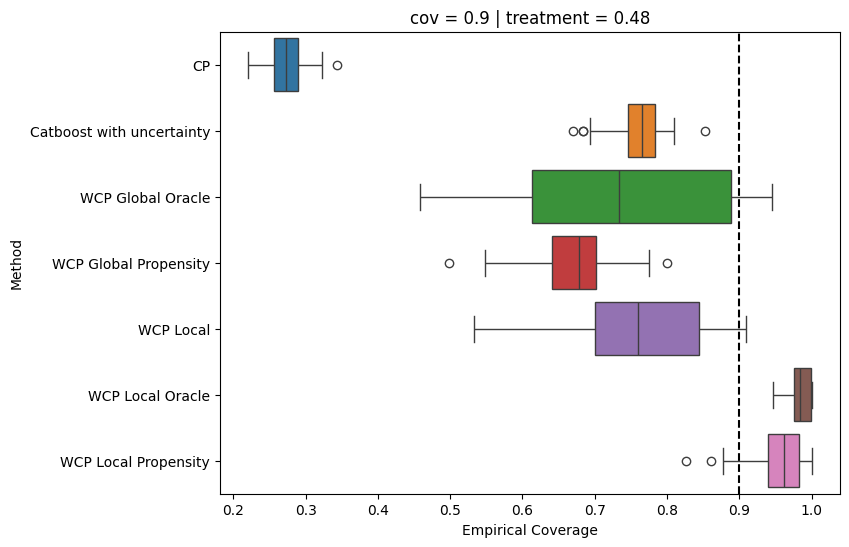

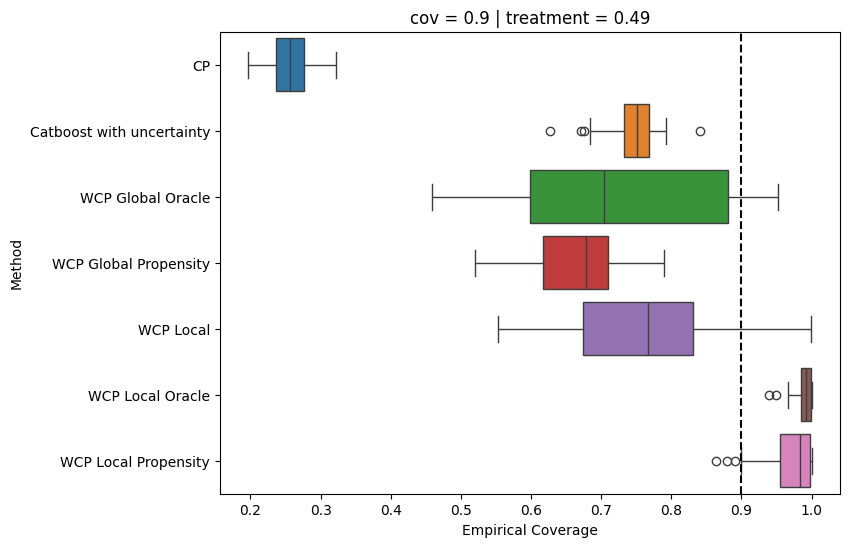

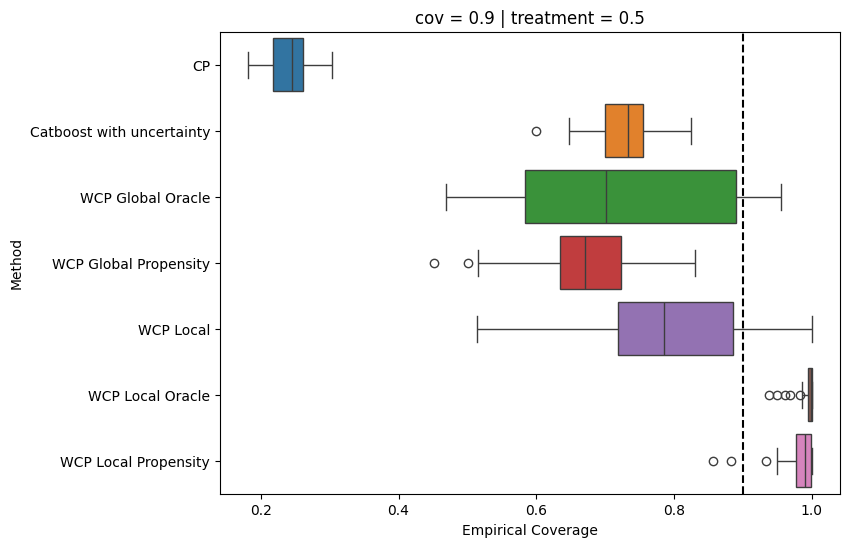

In [96]:
import seaborn as sns

for plot_treatment in all_results_df["treatment"].unique():
    required_cov = 0.9
    repeat_numb_test = all_results_df[(all_results_df.treatment == plot_treatment)&(all_results_df.confidence == required_cov)&(all_results_df.repeat_numb.isin(np.arange(0,50,1)))][["repeat_numb","Method","Empirical Coverage"]].groupby(["Method","repeat_numb"]).mean().reset_index()

    fig, axs = plt.subplots(1, 1, figsize=(8,6))
    
    sns.boxplot(
        repeat_numb_test, x="Empirical Coverage", y="Method", hue="Method", ax=axs #width=.6, palette="vlag"
    )
    axs.axvline(x = required_cov, color="black", linestyle="--")
    axs.set_title(f"cov = {required_cov} | treatment = {plot_treatment}")

    plt.show()